# Трансформеры в компьютерном зрении
## Computer Vision with Transformers

Преподаватель: Иванов Александр, Т-Банк

Аудитория: ФКН ВШЭ, МФТИ

Дата: 27.02.2026

---

### Структура лекции:

1. **Building Blocks** 
 - Архитектурные компоненты трансформеров
2. **Train/Inference** 
 - Механизмы обучения и инференса
3. **Architectures** 
 - BERT, ViT, Swin
4. **Text-Image Contrastive**
 - CLIP, CoCa, SigLip, BLIP
5. **NaViT/NaFleX** 
 - Работа с изображениями переменного разрешения



In [1]:
# Установка необходимых библиотек
!pip install torch torchvision transformers pillow matplotlib numpy scipy scikit-learn open_clip_torch

Looking in indexes: https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 7.2 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple
import math
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
device = 'cuda' if torch.cuda.is_available() else 'cpu'

---
# Часть 1: Building Blocks
## Attention is All You Need
 - Ключевые компоненты
### 1.1 Механизм Attention

**Интуиция**: Attention позволяет модели фокусироваться на релевантных частях входных данных при обработке каждого элемента последовательности.

#### Математическая формулировка

Базовый механизм Scaled Dot-Product Attention определяется как:
$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$
где:
- $Q \in \mathbb{R}^{n \times d_k}$ - Query (запросы)
- $K \in \mathbb{R}^{m \times d_k}$ - Keys (ключи)
- $V \in \mathbb{R}^{m \times d_v}$ - Values (значения)
- $d_k$ - размерность ключей/запросов
- $n$ - длина последовательности запросов
- $m$ - длина последовательности ключей/значений**Почему деление на $\sqrt{d_k}$?

**При больших $d_k$ скалярное произведение $QK^T$ может принимать очень большие значения, что приводит softmax в области с экстремально малыми градиентами. Покажем это:Пусть компоненты $Q$ и $K$ - независимые случайные величины с $\mathbb{E}[q_i] = \mathbb{E}[k_i] = 0$ и $\text{Var}(q_i) = \text{Var}(k_i) = 1$.Тогда для скалярного произведения $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$:
$$
\mathbb{E}[q \cdot k] = \sum_{i=1}^{d_k} \mathbb{E}[q_i k_i] = 0
$$$$
\text{Var}(q \cdot k) = \sum_{i=1}^{d_k} \text{Var}(q_i k_i) = d_k
$$
Стандартное отклонение растёт как $\sqrt{d_k}$, поэтому деление на $\sqrt{d_k}$ нормализует дисперсию к 1.

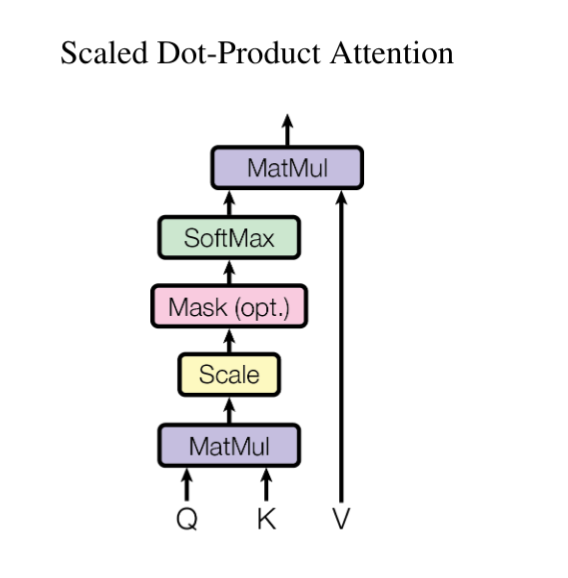
СХЕМА SCALED DOT-PRODUCT ATTENTION ИЗ СТАТЬИ "ATTENTION IS ALL YOU NEED" 

In [4]:
class ScaledDotProductAttention(nn.Module):
    """Базовый механизм scaled dot-product attention"""
    def __init__(self, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
    def forward(        self,         query: torch.Tensor,  # (batch, n_heads, seq_len_q, d_k)
        key: torch.Tensor,    # (batch, n_heads, seq_len_k, d_k)
        value: torch.Tensor,  # (batch, n_heads, seq_len_v, d_v)
        mask: Optional[torch.Tensor] = None  # (batch, 1, seq_len_q, seq_len_k)
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        d_k = query.size(-1)
        # Вычисляем attention scores: Q @ K^T / sqrt(d_k)
        scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
        # Применяем маску (заменяем masked позиции на -inf)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        # Применяем softmax для получения весов attention
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        # Взвешенная сумма values
        output = torch.matmul(attn_weights, value)
        return output, attn_weights
# Демонстрация работы attention
torch.manual_seed(42)
batch_size, n_heads, seq_len, d_k = 2, 8, 10, 64
Q = torch.randn(batch_size, n_heads, seq_len, d_k)
K = torch.randn(batch_size, n_heads, seq_len, d_k)
V = torch.randn(batch_size, n_heads, seq_len, d_k)
attention = ScaledDotProductAttention()
output, weights = attention(Q, K, V)
print(f"Query shape: {Q.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {weights.shape}")

Query shape: torch.Size([2, 8, 10, 64])
Output shape: torch.Size([2, 8, 10, 64])
Attention weights shape: torch.Size([2, 8, 10, 10])


### 1.2 Виды Attention
#### Self-Attention

В self-attention все три матрицы $Q$, $K$, $V$ получаются из одного и того же входа $X$:
$$
Q = XW^Q, \quad K = XW^K, \quad V = XW^V
$$
где $W^Q, W^K, W^V$ - обучаемые матрицы проекций.

**Применение**: Позволяет каждому элементу последовательности "обращать внимание" на все другие элементы этой же последовательности. Используется в энкодерах для построения контекстуальных представлений.

**Математическое свойство**: Self-attention инвариантен к перестановкам (permutation invariant) без positional encodings:
$$
\text{Attention}(P X, P X, P X) = P \cdot \text{Attention}(X, X, X)
$$
где $P$ - матрица перестановки.

#### Cross-Attention

В cross-attention запросы $Q$ приходят из одного источника, а ключи $K$ и значения $V$ - из другого:
$$
Q = X_{target}W^Q, \quad K = X_{source}W^K, \quad V = X_{source}W^V
$$

**Применение**: Используется в декодерах для связи между двумя модальностями:
- В машинном переводе: decoder обращается к encoder representations
- В Vision Transformers: связь между изображением и текстом
- В multimodal моделях: связь между разными модальностями

**Зачем нужен cross-attention?**

1. **Условная генерация**: Позволяет генерировать выход, обусловленный входом из другой модальности
2. **Information bottleneck**: Декодер может выборочно извлекать релевантную информацию из энкодера
3. **Architectural flexibility**: Можно использовать разные размерности для encoder и decoder

**Пример**: В модели image captioning:- Encoder обрабатывает изображение → получаем $H_{image}$- Decoder генерирует текст, используя cross-attention к $H_{image}$- На каждом шаге генерации decoder "смотрит" на релевантные части изображения

In [6]:
class MultiHeadAttention(nn.Module):
    """Multi-head attention с поддержкой self и cross attention"""
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model должен делиться на n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        # Проекции для Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        # Выходная проекция
        self.W_o = nn.Linear(d_model, d_model)
        self.attention = ScaledDotProductAttention(dropout)
        self.dropout = nn.Dropout(dropout)
    def forward(        self,         query: torch.Tensor,  # (batch, seq_len_q, d_model)
        key: torch.Tensor,    # (batch, seq_len_k, d_model)
        value: torch.Tensor,  # (batch, seq_len_v, d_model)
        mask: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        batch_size = query.size(0)
        # Линейные проекции и разбиение на heads
        Q = self.W_q(query).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        # Применяем attention
        attn_output, _ = self.attention(Q, K, V, mask)
        # Concatenate heads и применяем выходную проекцию
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.W_o(attn_output)
        return self.dropout(output)
        
# Демонстрация self-attention и cross-attention
d_model, n_heads = 512, 8
mha = MultiHeadAttention(d_model, n_heads)
# Self-attention: Q, K, V из одного источника
x = torch.randn(2, 10, d_model)
self_attn_out = mha(x, x, x)
print(f"Self-attention output shape: {self_attn_out.shape}")
# Cross-attention: Q из одного источника, K, V из другого
query_seq = torch.randn(2, 5, d_model)  # decoder sequence
context_seq = torch.randn(2, 10, d_model)  # encoder sequence
cross_attn_out = mha(query_seq, context_seq, context_seq)
print(f"Cross-attention output shape: {cross_attn_out.shape}")

Self-attention output shape: torch.Size([2, 10, 512])
Cross-attention output shape: torch.Size([2, 5, 512])


### 1.3 Multi-Head Attention

**Зачем нужны множественные головы?**

Multi-head attention позволяет модели одновременно обращать внимание на информацию из разных подпространств представлений:
$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O
$$
где каждая голова:
$$
\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)
$$

**Теоретическое обоснование**:

1. **Разные типы зависимостей**: Разные головы могут специализироваться на различных типах отношений (позиционные, семантические, синтаксические)
2. **Ensemble эффект**: Аналогично ensemble методам в ML, несколько голов снижают variance
3. **Rank увеличение**: Одна голова ограничена rank матрицы внимания $\text{rank}(\text{Attention}) \leq \min(n, d_k)$. Множественные головы увеличивают выразительность
4. **Разные масштабы**: Головы могут фокусироваться на разных масштабах взаимодействий (локальные vs глобальные)

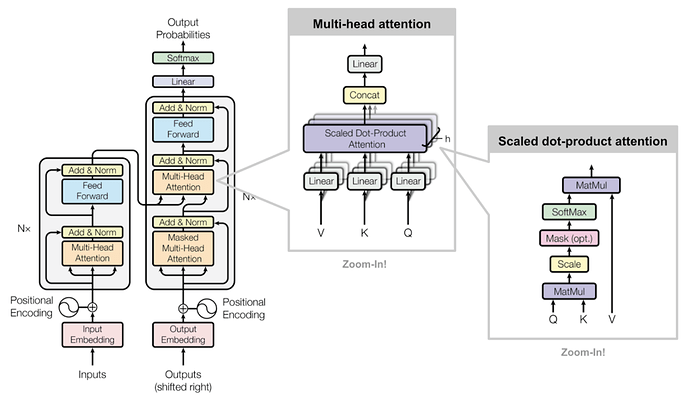

СХЕМА MULTI-HEAD ATTENTION ИЗ "ATTENTION IS ALL YOU NEED" 

### 1.4 Маски внимания

Маски используются для управления тем, какие позиции могут влиять друг на друга.

#### Padding Mask

Игнорирует padding токены в батчах последовательностей разной длины:
$$
\text{mask}_{ij} = \begin{cases} 0, & \text{если } j \text{ - padding} \\1, & \text{иначе}\end{cases}
$$

#### Causal Mask (Look-ahead mask)

Используется в декодерах для предотвращения "подглядывания" в будущее:
$$
\text{mask}_{ij} = \begin{cases} 1, & \text{если } i \geq j \\0, & \text{если } i < j\end{cases}
$$

Это гарантирует автореггрессивность: предсказание позиции $i$ зависит только от позиций $< i$.

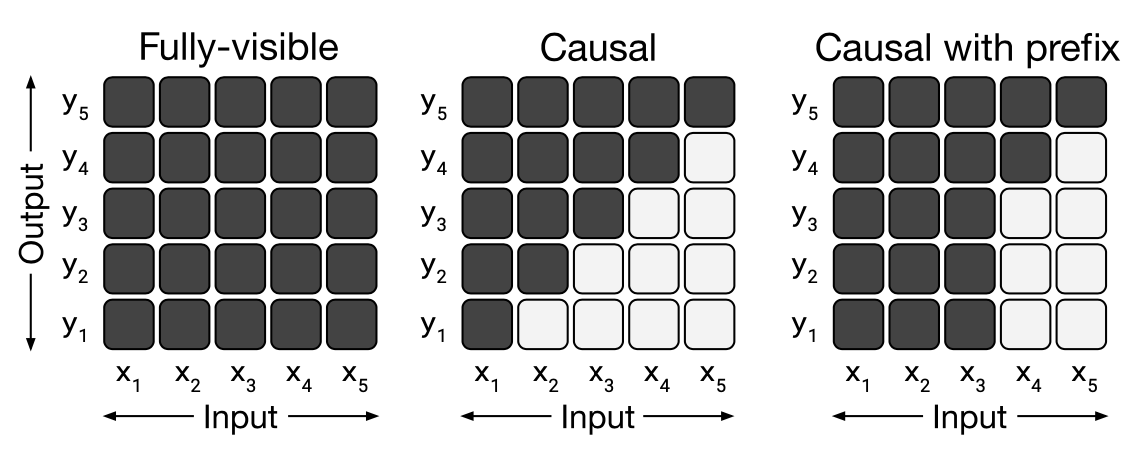

#### Attention Mask в Vision

В компьютерном зрении маски используются для:
- **Sparse attention**: ограничение внимания на локальные окна (Swin Transformer)
- **Variable resolution**: маскирование padding патчей при батчинге изображений разных размеров
- **Hierarchical attention**: разные уровни пирамиды признаков
- 
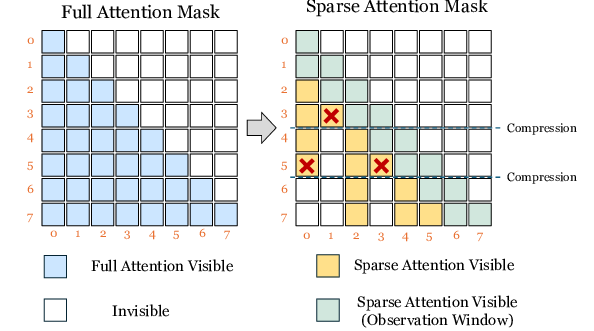

SPARSE ATTENTION MASK EXAMPLE

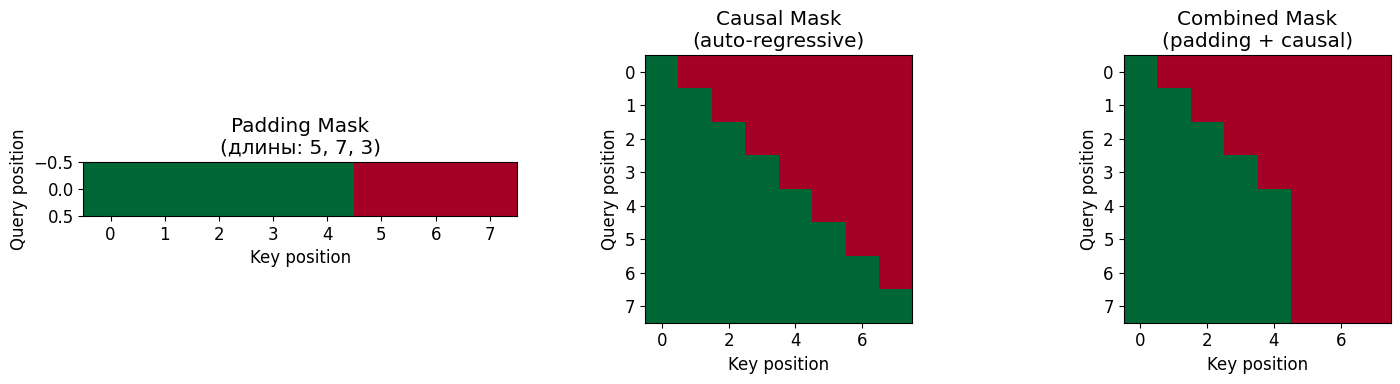

Белый = разрешено, Красный = замаскировано


In [7]:
def create_padding_mask(seq_lens: torch.Tensor, max_len: int) -> torch.Tensor:
    """Создает padding mask для батча последовательностей разной длины"""
    batch_size = seq_lens.size(0)
    mask = torch.arange(max_len).expand(batch_size, max_len) < seq_lens.unsqueeze(1)
    return mask.unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, max_len)

def create_causal_mask(seq_len: int) -> torch.Tensor:
    """Создает causal (look-ahead) mask для decoder"""
    mask = torch.tril(torch.ones(seq_len, seq_len))
    return mask.unsqueeze(0).unsqueeze(0)  # (1, 1, seq_len, seq_len)
    
# Визуализация масок
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Padding mask
seq_lens = torch.tensor([5, 7, 3])
padding_mask = create_padding_mask(seq_lens, 8)
axes[0].imshow(padding_mask[0, 0].float(), cmap='RdYlGn', vmin=0, vmax=1)
axes[0].set_title('Padding Mask\n(длины: 5, 7, 3)')
axes[0].set_xlabel('Key position')
axes[0].set_ylabel('Query position')
# Causal mask
causal_mask = create_causal_mask(8)
axes[1].imshow(causal_mask[0, 0], cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_title('Causal Mask\n(auto-regressive)')
axes[1].set_xlabel('Key position')
axes[1].set_ylabel('Query position')
# Combined mask
combined_mask = padding_mask[0] * causal_mask
axes[2].imshow(combined_mask[0, 0], cmap='RdYlGn', vmin=0, vmax=1)
axes[2].set_title('Combined Mask\n(padding + causal)')
axes[2].set_xlabel('Key position')
axes[2].set_ylabel('Query position')
plt.tight_layout()
plt.savefig('attention_masks.png', dpi=150, bbox_inches='tight')
plt.show()
print("Белый = разрешено, Красный = замаскировано")

### 1.5 Feed-Forward Networks (MLP)

После attention каждая позиция последовательности независимо проходит через двухслойный MLP:
$$
\text{FFN}(x) = \text{GELU}(xW_1 + b_1)W_2 + b_2
$$

**Типичная конфигурация**:
- Входная размерность: $d_{model}$ (например, 768)
- Скрытая размерность: $d_{ff} = 4 \cdot d_{model}$ (например, 3072)
- Выходная размерность: $d_{model}$

**Зачем нужен MLP?**

1. **Нелинейные преобразования**: Attention - это линейная операция (weighted sum). MLP добавляет нелинейность
2. **Position-wise processing**: Обрабатывает каждую позицию независимо, интегрируя информацию собранную attention
3. **Capacity**: Основная вычислительная сложность и количество параметров трансформера сосредоточены в MLP

**Activation functions**:
- **ReLU**: $\text{ReLU}(x) = \max(0, x)$ - оригинальная статья
- **GELU**: $\text{GELU}(x) = x \cdot \Phi(x)$ где $\Phi$ - CDF стандартного нормального распределения
  - Используется в BERT, GPT-3, ViT
  - Более гладкая, чем ReLU
  - Приближение: $\text{GELU}(x) \approx 0.5x(1 + \tanh[\sqrt{2/\pi}(x + 0.044715x^3)])$


### 1.6 Encoder Block

Encoder block состоит из:

1. **Multi-Head Self-Attention** с residual connection и layer normalization
2. **Feed-Forward Network** с residual connection и layer normalization
   
$$
\begin{align}\tilde{X} &= \text{LayerNorm}(X + \text{MultiHead}(X, X, X)) \\Z &= \text{LayerNorm}(\tilde{X} + \text{FFN}(\tilde{X}))\end{align}
$$
**Layer Normalization**:
$$
\text{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta
$$
где $\mu$ и $\sigma^2$ вычисляются по последней размерности (features), в отличие от Batch Norm.

**Преимущества LayerNorm**:- Не зависит от batch size
- Работает для последовательностей разной длины
- Стабилизирует обучение глубоких сетей

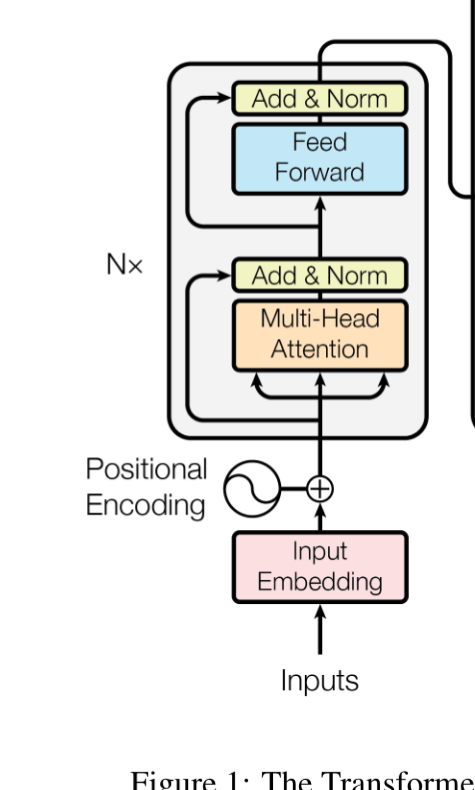 

СХЕМА ENCODER BLOCK ИЗ "ATTENTION IS ALL YOU NEED" 

In [9]:
class FeedForward(nn.Module):
    """Position-wise Feed-Forward Network"""
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        return self.linear2(self.dropout(F.gelu(self.linear1(x))))

class EncoderBlock(nn.Module):            
    """Transformer Encoder Block"""
    def __init__(        
        self,         
        d_model: int,         
        n_heads: int,         
        d_ff: int,         
        dropout: float = 0.1,
    ):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(        
        self,         
        x: torch.Tensor,         
        mask: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        # Self-attention с residual connection
        attn_out = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        # Feed-forward с residual connection
        ff_out = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x
        
# Демонстрация encoder block
d_model, n_heads, d_ff = 512, 8, 4096
encoder_block = EncoderBlock(d_model, n_heads, d_ff)
x = torch.randn(2, 10, d_model)
output = encoder_block(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

# Подсчет параметров
total_params = sum(p.numel() for p in encoder_block.parameters())
attn_params = sum(p.numel() for p in encoder_block.self_attn.parameters())
ff_params = sum(p.numel() for p in encoder_block.feed_forward.parameters())

print(f"\nПараметры encoder block:")
print(f"Total: {total_params:,}")
print(f"Attention: {attn_params:,} ({100*attn_params/total_params:.1f}%)")
print(f"Feed-forward: {ff_params:,} ({100*ff_params/total_params:.1f}%)")

Input shape: torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])

Параметры encoder block:
Total: 5,251,584
Attention: 1,050,624 (20.0%)
Feed-forward: 4,198,912 (80.0%)


### 1.7 Decoder Block

Decoder block изначально расширяет encoder block, добавляя cross-attention:

1. **Masked Multi-Head Self-Attention** (causal mask)
2. **Multi-Head Cross-Attention** (к encoder outputs)
3. **Feed-Forward Network**Все с residual connections и layer normalization:
   
$$
\begin{align}\tilde{X} &= \text{LayerNorm}(X + \text{MaskedSelfAttn}(X, X, X)) \\\hat{X} &= \text{LayerNorm}(\tilde{X} + \text{CrossAttn}(\tilde{X}, H_{enc}, H_{enc})) \\Z &= \text{LayerNorm}(\hat{X} + \text{FFN}(\hat{X}))\end{align}
$$
где $H_{enc}$ - выходы энкодера.

**Почему именно такой порядок?**

1. **Self-attention сначала**: Decoder сначала анализирует уже сгенерированную последовательность
2. **Cross-attention потом**: На основе контекста из self-attention decoder выборочно извлекает информацию из encoder
3. **FFN в конце**: Интегрирует и преобразует собранную информацию

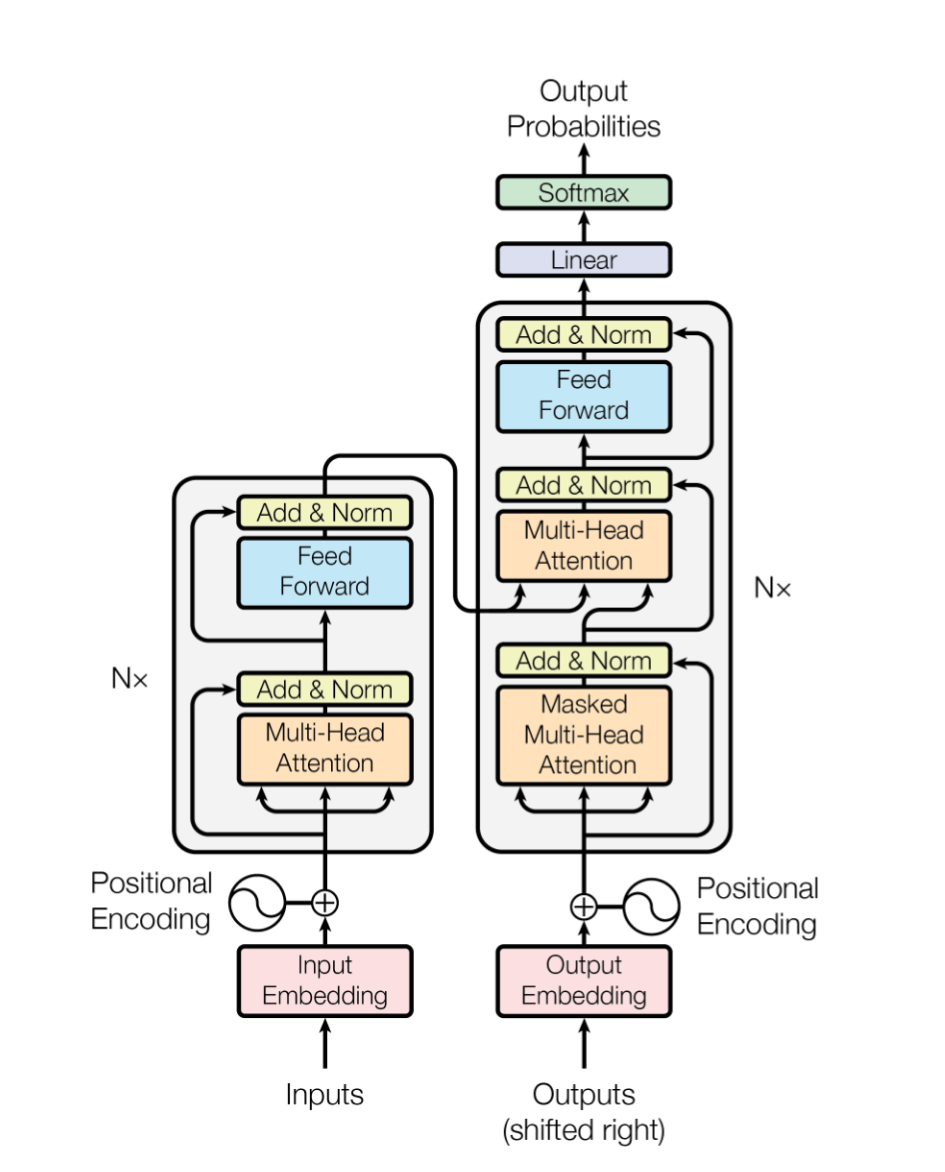

СХЕМА DECODER BLOCK ИЗ "ATTENTION IS ALL YOU NEED" 

### 1.8 Dropout в TransformerDropout применяется в нескольких местах:

1. **Attention dropout**: После softmax в attention weights
2. **Residual dropout**: После каждого sub-layer перед добавлением к residual connection
3. **FFN dropout**: После активации в feed-forward network
  
**Зачем dropout в разных местах?**:

- **Attention dropout**: Регуляризует attention patterns, предотвращая overconfidence
- **Residual dropout**: Регуляризует gradient flow через residual connections
- **FFN dropout**: Стандартная регуляризация MLP

In [11]:
class DecoderBlock(nn.Module):
    """Transformer Decoder Block with cross-attention"""
    def __init__(        
        self,         
        d_model: int,         
        n_heads: int,         
        d_ff: int,         
        dropout: float = 0.1
    ):
        super().__init__()
        # Masked self-attention
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        # Cross-attention к encoder outputs
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        # Feed-forward
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        # Layer normalizations
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(        
        self,         
        x: torch.Tensor,  # decoder input
        encoder_output: torch.Tensor,  # encoder output
        self_attn_mask: Optional[torch.Tensor] = None,  # causal mask
        cross_attn_mask: Optional[torch.Tensor] = None  # encoder padding mask
    ) -> torch.Tensor:
        # 1. Masked self-attention
        self_attn_out = self.self_attn(x, x, x, self_attn_mask)
        x = self.norm1(x + self.dropout(self_attn_out))
        # 2. Cross-attention к encoder
        cross_attn_out = self.cross_attn(x, encoder_output, encoder_output, cross_attn_mask)
        x = self.norm2(x + self.dropout(cross_attn_out))
        # 3. Feed-forward
        ff_out = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_out))
        return x
        
# Демонстрация decoder block
decoder_block = DecoderBlock(d_model, n_heads, d_ff)
# Decoder input (частично сгенерированная последовательность)
decoder_input = torch.randn(2, 5, d_model)
# Encoder output (закодированный source)
encoder_output = torch.randn(2, 10, d_model)
# Causal mask для decoder self-attention
causal_mask = create_causal_mask(5)
output = decoder_block(decoder_input, encoder_output, causal_mask)
print(f"Decoder input shape: {decoder_input.shape}")
print(f"Encoder output shape: {encoder_output.shape}")
print(f"Decoder output shape: {output.shape}")

# Подсчет параметров
total_params = sum(p.numel() for p in decoder_block.parameters())
self_attn_params = sum(p.numel() for p in decoder_block.self_attn.parameters())
cross_attn_params = sum(p.numel() for p in decoder_block.cross_attn.parameters())
ff_params = sum(p.numel() for p in decoder_block.feed_forward.parameters())
print(f"\nПараметры decoder block:")
print(f"Total: {total_params:,}")
print(f"Self-attention: {self_attn_params:,} ({100*self_attn_params/total_params:.1f}%)")
print(f"Cross-attention: {cross_attn_params:,} ({100*cross_attn_params/total_params:.1f}%)")
print(f"Feed-forward: {ff_params:,} ({100*ff_params/total_params:.1f}%)")

Decoder input shape: torch.Size([2, 5, 512])
Encoder output shape: torch.Size([2, 10, 512])
Decoder output shape: torch.Size([2, 5, 512])

Параметры decoder block:
Total: 6,303,232
Self-attention: 1,050,624 (16.7%)
Cross-attention: 1,050,624 (16.7%)
Feed-forward: 4,198,912 (66.6%)


### 1.9 Продвинутая оптимизация: Mixture of Experts (MoE)

**Идея**: Вместо одного большого FFN использовать множество "экспертов" (FFN), но активировать только некоторых для каждого токена.

#### Архитектура MoE
$$
\text{MoE}(x) = \sum_{i=1}^{N} G(x)_i \cdot E_i(x)
$$
где:
- $E_i$ - $i$-й эксперт (FFN)
- $G(x)$ - gating network, определяет веса экспертов
- $N$ - общее число экспертов
- Обычно активируются только top-k экспертов (k=1 или k=2)
  
#### Gating Network
$$
G(x) = \text{Softmax}(\text{TopK}(x \cdot W_g))
$$
где $\text{TopK}$ обнуляет все кроме k наибольших значений.

#### Оценка экономии ресурсов

**Стандартный FFN**:
- Параметры: $2 \cdot d_{model} \cdot d_{ff}$- FLOPs на токен: $2 \cdot d_{model} \cdot d_{ff}$
  
**MoE с N экспертами, top-k активации**:
- Параметры: $N \cdot 2 \cdot d_{model} \cdot d_{ff}$ (в N раз больше!)
- FLOPs на токен: $k \cdot 2 \cdot d_{model} \cdot d_{ff}$ (только k экспертов активны)
- Gating overhead: $d_{model} \cdot N$ (обычно пренебрежимо мало)

**Пример**: GPT-4 (слухи):- N = 16 экспертов
- k = 2 активных
- Параметры: ~1.7T (16 экспертов × ~100B каждый)
- Активные параметры при инференсе: ~200B (2 эксперта)
- **FLOPs экономия**: $\frac{16}{2} = 8\times$ меньше vs полной модели 1.7T параметров
  
**Switch Transformer** (Google, 2021):
- N = 2048 экспертов
- k = 1 активный
- Модель 1.6T параметров
- FLOPs как у модели 10B параметров
- **Ускорение обучения**: ~4x vs эквивалентной плотной модели

#### Load Balancing

**Проблема**: 

Эксперты могут специализироваться неравномерно → некоторые перегружены, другие не используются.

**Решение**: Auxiliary load balancing loss:
$$
\mathcal{L}_{aux} = \alpha \cdot N \cdot \sum_{i=1}^{N} f_i \cdot P_i
$$
где:
- $f_i$ - доля токенов, направленных к эксперту $i$- $P_i$ - средняя вероятность от gating для эксперта $i$- $\alpha$ - коэффициент (обычно 0.01)Минимизация $\mathcal{L}_{aux}$ поощряет равномерное распределение.

#### Преимущества MoE:
1. **Масштабирование модели** без пропорционального роста compute
2. **Специализация**: Разные эксперты для разных типов входов
3. **Эффективность**: Inference близок к small model, capacity как у large model
4. 
#### Недостатки:
1. **Memory**: Все эксперты должны быть в памяти
2. **Communication**: В distributed setting требует all-to-all communication
3. **Сложность обучения**: Load balancing, stability issues
4. **Fine-tuning**: Может быть нестабильным

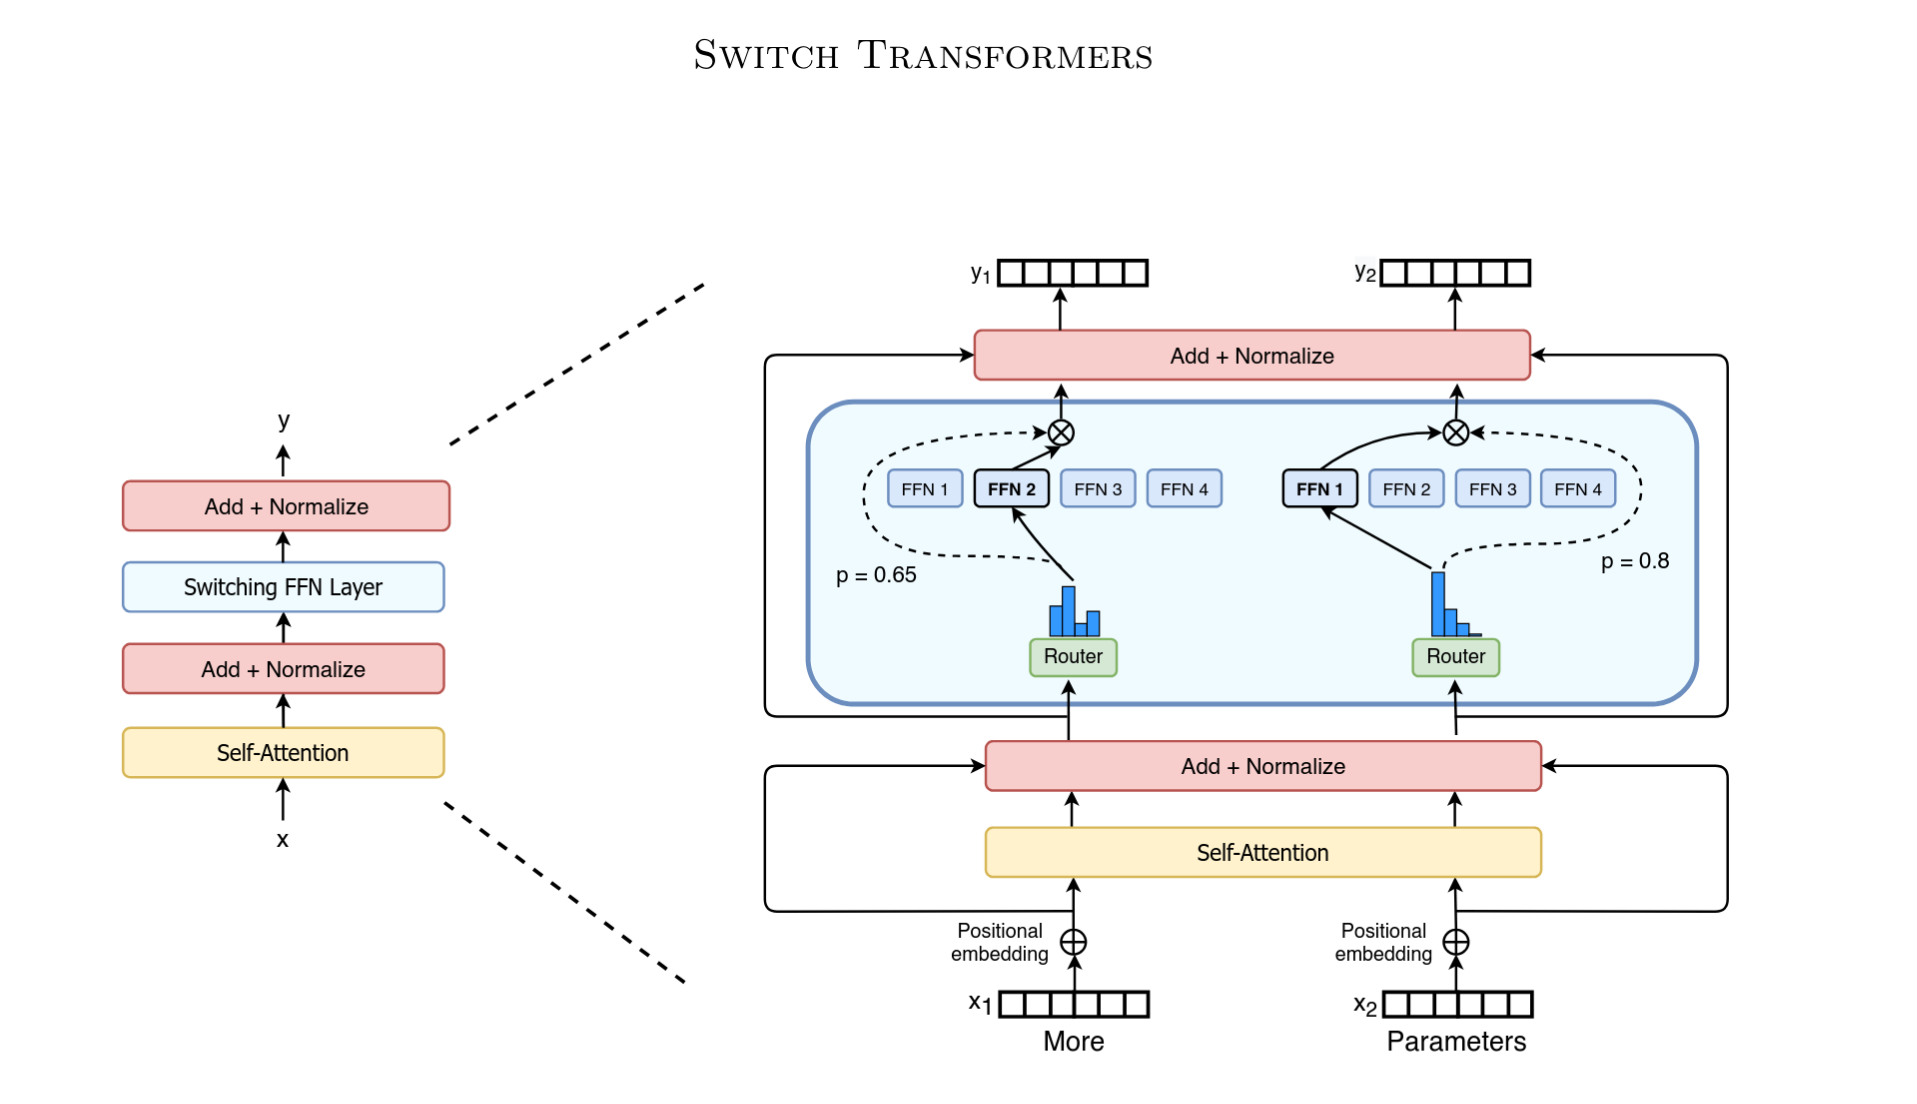 СХЕМА MIXTURE OF EXPERTS LAYER ИЗ СТАТЬИ "SWITCH TRANSFORMERS" 

In [12]:
class Expert(nn.Module):
    """Один эксперт - обычный FFN"""
    def __init__(self, d_model: int, d_ff: int):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc2(F.gelu(self.fc1(x)))
        
class MoELayer(nn.Module):
    """Mixture of Experts Layer with top-k gating"""
    def __init__(        
        self,         
        d_model: int,         
        d_ff: int,         
        num_experts: int,         
        top_k: int = 2,        
        load_balance_loss_coef: float = 0.01
    ):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.load_balance_loss_coef = load_balance_loss_coef
        # Создаем экспертов
        self.experts = nn.ModuleList([           
            Expert(d_model, d_ff) for _ in range(num_experts)
        ])
        # Gating network
        self.gate = nn.Linear(d_model, num_experts)
        
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        batch_size, seq_len, d_model = x.shape
        x_flat = x.view(-1, d_model)  # (batch * seq_len, d_model)
        # Вычисляем gating scores
        gate_logits = self.gate(x_flat)  # (batch * seq_len, num_experts)
        # Top-k selection
        top_k_logits, top_k_indices = torch.topk(gate_logits, self.top_k, dim=-1)
        top_k_gates = F.softmax(top_k_logits, dim=-1)
        # Инициализируем выход
        output = torch.zeros_like(x_flat)
        # Применяем экспертов
        for i, expert in enumerate(self.experts):
            # Находим токены, для которых эксперт i в top-k
            expert_mask = (top_k_indices == i).any(dim=-1)
            if expert_mask.any():
                expert_input = x_flat[expert_mask]
                expert_output = expert(expert_input)
                # Получаем веса для этого эксперта
                expert_positions = (top_k_indices == i).long()
                expert_weights = (top_k_gates * expert_positions).sum(dim=-1, keepdim=True)
                expert_weights = expert_weights[expert_mask]
                output[expert_mask] += expert_weights * expert_output
        # Load balancing loss
        gate_probs = F.softmax(gate_logits, dim=-1)
        expert_usage = gate_probs.mean(dim=0)  # Доля использования каждого эксперта
        expert_importance = gate_probs.sum(dim=0)  # Суммарная важность
        load_balance_loss = self.num_experts * (expert_usage * expert_importance).sum()
        return output.view(batch_size, seq_len, d_model), load_balance_loss
        
# Демонстрация MoE
d_model, d_ff, num_experts = 512, 2048, 8
moe = MoELayer(d_model, d_ff, num_experts, top_k=2)
x = torch.randn(2, 10, d_model)
output, lb_loss = moe(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Load balance loss: {lb_loss.item():.4f}")

# Сравнение параметров
dense_ffn_params = 2 * d_model * d_ff
moe_params = num_experts * 2 * d_model * d_ff + d_model * num_experts
print(f"\nСравнение параметров:")
print(f"Dense FFN: {dense_ffn_params:,}")
print(f"MoE ({num_experts} experts): {moe_params:,}")
print(f"Ratio: {moe_params / dense_ffn_params:.1f}x больше параметров")
print(f"\nНо активируются только {moe.top_k}/{num_experts} экспертов")
print(f"Активные FLOPs ratio: {moe.top_k}/{num_experts} = {moe.top_k/num_experts:.2f}x")

Input shape: torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])
Load balance loss: 20.1562

Сравнение параметров:
Dense FFN: 2,097,152
MoE (8 experts): 16,781,312
Ratio: 8.0x больше параметров

Но активируются только 2/8 экспертов
Активные FLOPs ratio: 2/8 = 0.25x


---
## 1.10 Positional Embeddings

**Проблема**: 

Attention механизм инвариантен к перестановкам - без позиционной информации модель не различает порядок токенов.

Для последовательностей $x_1, x_2, ..., x_n$ и любой перестановки $\pi$:
$$
\text{Attention}(x_{\pi(1)}, x_{\pi(2)}, ..., x_{\pi(n)}) = \pi(\text{Attention}(x_1, x_2, ..., x_n))
$$

**Решение**: Добавить позиционную информацию к входным эмбеддингам.

### 1.10.1 Что если НЕ использовать positional embeddings?

Проведем эксперимент:

In [13]:
# Эксперимент: Self-attention без позиционной информации
class SimpleAttention(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(x.size(-1))
        attn = F.softmax(scores, dim=-1)
        return torch.matmul(attn, V)
        
torch.manual_seed(42)
d_model = 64
attn = SimpleAttention(d_model)
        
# Создаем две последовательности: оригинальную и переставленную
original = torch.randn(1, 5, d_model)
permuted = original[:, [4, 2, 0, 3, 1], :]  

out_original = attn(original)
out_permuted = attn(permuted)
# Применяем обратную перестановку к выходу
out_permuted_restored = out_permuted[:, [2, 4, 1, 3, 0], :]
# Сравниваем
diff = (out_original - out_permuted_restored).abs().max()

print(f"Максимальная разница между original и permuted: {diff.item():.6f}")
print("\n⚠️ Внимание не различает порядок элементов!")
print("Модель не знает, что 'кот ест мышь' != 'мышь ест кот'")

Максимальная разница между original и permuted: 0.000000

⚠️ Внимание не различает порядок элементов!
Модель не знает, что 'кот ест мышь' != 'мышь ест кот'


### 1.10.2 Обучаемые Positional Embeddings

**Самый простой подход**: 

Создать таблицу обучаемых векторов 

$PE \in \mathbb{R}^{L_{max} \times d_{model}}$:
$$
\tilde{x}_i = x_i + PE[i]
$$
где $i$ - позиция в последовательности, $L_{max}$ - максимальная длина.

**Преимущества**:

- Простота реализации
- Модель сама обучает оптимальные позиционные представления
- Используется в BERT, GPT-2, ViT, SigLIP

**Недостатки**:
- Ограничена фиксированной максимальной длиной $L_{max}$
- Не может экстраполироваться на длины > $L_{max}$
- Требует дополнительные параметры: $L_{max} \times d_{model}$

Input shape: torch.Size([2, 20, 512])
Output shape: torch.Size([2, 20, 512])
Параметры: 51,200


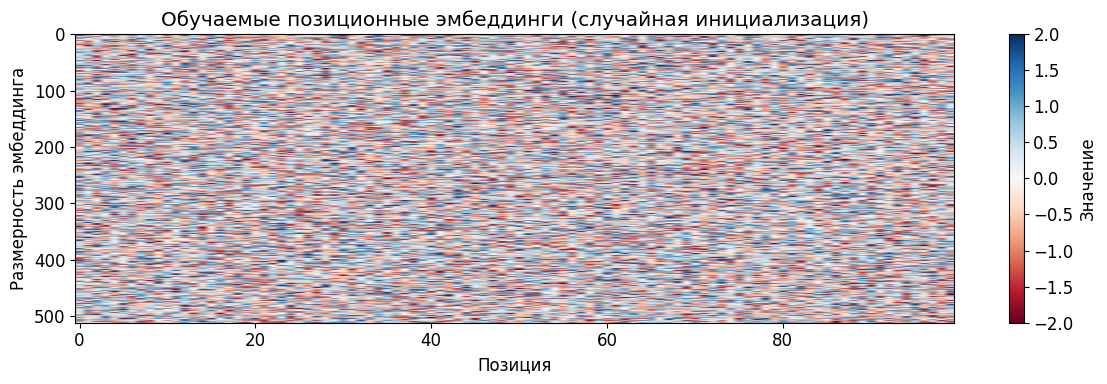

In [14]:
class LearnedPositionalEmbedding(nn.Module):
    """Обучаемые позиционные эмбеддинги"""
    def __init__(self, max_len: int, d_model: int):
        super().__init__()
        self.pe = nn.Parameter(torch.randn(max_len, d_model))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        seq_len = x.size(1)
        return x + self.pe[:seq_len]
        
# Демонстрация
max_len, d_model = 100, 512
learned_pe = LearnedPositionalEmbedding(max_len, d_model)
x = torch.randn(2, 20, d_model)
x_with_pos = learned_pe(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {x_with_pos.shape}")
print(f"Параметры: {max_len * d_model:,}")
# Визуализация обученных позиционных эмбеддингов
plt.figure(figsize=(12, 4))
plt.imshow(learned_pe.pe.detach().numpy().T, aspect='auto', cmap='RdBu', vmin=-2, vmax=2)
plt.colorbar(label='Значение')
plt.xlabel('Позиция')
plt.ylabel('Размерность эмбеддинга')
plt.title('Обучаемые позиционные эмбеддинги (случайная инициализация)')
plt.tight_layout()
plt.show()

### 1.10.3 Sinusoidal Positional Embeddings

**Идея** (из оригинальной статьи "Attention is All You Need"): 

Использовать фиксированные синусоиды разных частот.

$$
PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$$$
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$
где:
- $pos$ - позиция в последовательности
- $i$ - индекс размерности ($i \in [0, d_{model}/2)$)
- Четные размерности
 - синус, нечетные
 - косинус

**Интуиция**: 
- Низкие частоты (малые $i$) для грубой позиционной информации
- Высокие частоты (большие $i$) для точной позиционной информации
- Аналогия с двоичным представлением чисел

**Почему это работает?

**1. **Линейная зависимость**: 

Для фиксированного смещения $k$:   
$$
PE_{pos+k} = A \cdot PE_{pos} + B \cdot PE_{pos}
$$
где $A$, $B$ - матрицы, зависящие только от $k$ (не от $pos$).   
Это позволяет модели обучиться относительным позициям.

2. **Периодичность**: Каждая размерность имеет период от $2\pi$ до $2\pi \cdot 10000$

3. **Уникальность**: Каждая позиция получает уникальный вектор
5. **Extrapolation**: Может работать с позициями > $L_{max}$, виденными при обучении
6. **Геометрическая интерпретация**: Разные частоты создают "спираль" в пространстве эмбеддингов. Близкие позиции имеют близкие векторы, дальние
 - различаются.

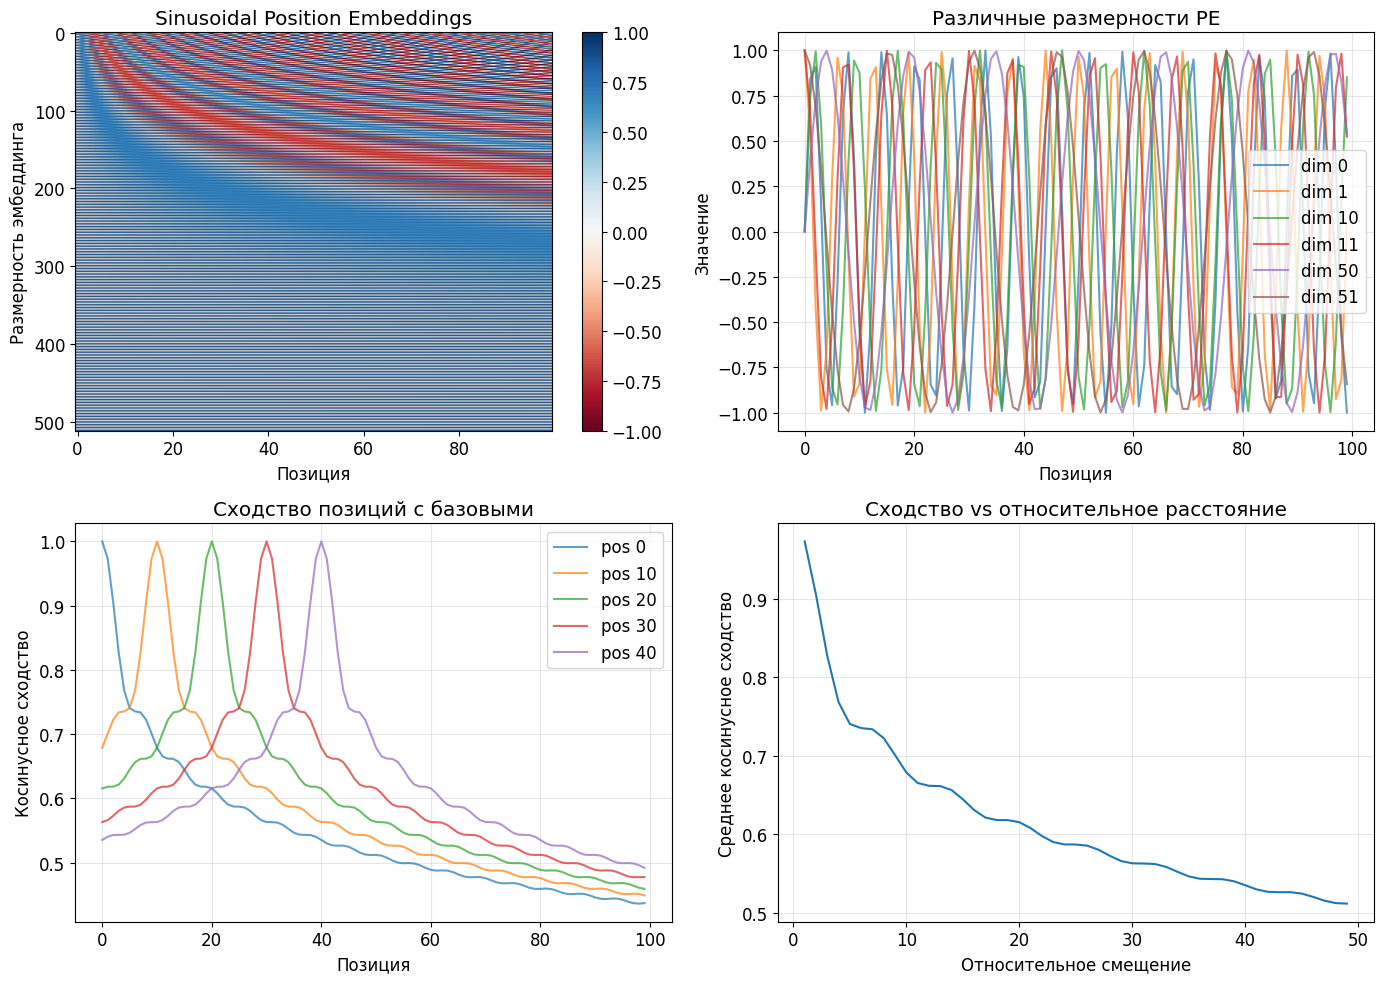

Sinusoidal PE создает регулярную структуру:
- Близкие позиции имеют высокое сходство
- Сходство зависит от относительного расстояния, а не абсолютных позиций


In [15]:
class SinusoidalPositionalEmbedding(nn.Module):
    """Sinusoidal позиционные эмбеддинги (Vaswani et al., 2017)"""
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        # Создаем матрицу позиционных эмбеддингов
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        # Вычисляем div_term: 10000^(2i/d_model)
        div_term = torch.exp(            
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        # Применяем sin к четным индексам, cos к нечетным
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        # Регистрируем как buffer (не обучаемый параметр)
        self.register_buffer('pe', pe)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        seq_len = x.size(1)
        return x + self.pe[:seq_len]
        
# Создаем sinusoidal embeddings
d_model = 512
sin_pe = SinusoidalPositionalEmbedding(d_model, max_len=100)
# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# 1. Heatmap всех позиций и размерностей
im1 = axes[0, 0].imshow(sin_pe.pe[:100].numpy().T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
axes[0, 0].set_xlabel('Позиция')
axes[0, 0].set_ylabel('Размерность эмбеддинга')
axes[0, 0].set_title('Sinusoidal Position Embeddings')

plt.colorbar(im1, ax=axes[0, 0])

# 2. Несколько размерностей как функции от позиции

dims_to_plot = [0, 1, 10, 11, 50, 51]

for dim in dims_to_plot:
    axes[0, 1].plot(sin_pe.pe[:100, dim].numpy(), label=f'dim {dim}', alpha=0.7)
axes[0, 1].set_xlabel('Позиция')
axes[0, 1].set_ylabel('Значение')
axes[0, 1].set_title('Различные размерности PE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Косинусное расстояние между позициями
positions = [0, 10, 20, 30, 40]
for pos in positions:
    similarities = F.cosine_similarity(        
        sin_pe.pe[pos:pos+1],         
        sin_pe.pe[:100],         
        dim=1
    )
    axes[1, 0].plot(similarities.numpy(), label=f'pos {pos}', alpha=0.7)
    
axes[1, 0].set_xlabel('Позиция')
axes[1, 0].set_ylabel('Косинусное сходство')
axes[1, 0].set_title('Сходство позиций с базовыми')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Относительные расстояния
distances = []
for offset in range(1, 50):
    dist = []
    for pos in range(50):
        d = F.cosine_similarity(            
            sin_pe.pe[pos:pos+1],            
            sin_pe.pe[pos+offset:pos+offset+1],            
            dim=1
        ).item()
        dist.append(d)
    distances.append(np.mean(dist))
    
axes[1, 1].plot(range(1, 50), distances)
axes[1, 1].set_xlabel('Относительное смещение')
axes[1, 1].set_ylabel('Среднее косинусное сходство')
axes[1, 1].set_title('Сходство vs относительное расстояние')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sinusoidal_pe_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sinusoidal PE создает регулярную структуру:")
print("- Близкие позиции имеют высокое сходство")
print("- Сходство зависит от относительного расстояния, а не абсолютных позиций")

### 1.10.4 Rotary Position Embeddings (RoPE)

**Проблема предыдущих подходов**: 

Позиционная информация добавляется к эмбеддингам перед attention, но не напрямую влияет на относительные взаимодействия в attention scores.

**Идея RoPE** (Su et al., 2021): 

Кодировать позицию напрямую в механизм attention через вращение в комплексной плоскости.

#### Математическая формулировка

Представим каждую пару размерностей как комплексное число. Для позиции $m$ применяем поворот:
$$
f_q(x_m, m) = (W_q x_m) e^{im\theta}
$$$$
f_k(x_n, n) = (W_k x_n) e^{in\theta}
$$
где $\theta$ - частота вращения.При вычислении attention score:
$$
q_m^T k_n = \text{Re}[(W_q x_m) e^{im\theta} \cdot \overline{(W_k x_n) e^{in\theta}}]
$$$$
= \text{Re}[(W_q x_m)(W_k x_n)^* e^{i(m-n)\theta}]
$$

**Ключевое свойство**: Score зависит только от относительной позиции $(m - n)$!

#### Реализация через матрицы вращения

Для каждой пары размерностей $(2i, 2i+1)$ с частотой $\theta_i = 10000^{-2i/d}$:
$$
\begin{pmatrix} q_{2i}^{(m)} \\ q_{2i+1}^{(m)} \end{pmatrix} = \begin{pmatrix} \cos(m\theta_i) & -\sin(m\theta_i) \\ \sin(m\theta_i) & \cos(m\theta_i) \end{pmatrix} \begin{pmatrix} q_{2i} \\ q_{2i+1} \end{pmatrix}
$$

#### Преимущества RoPE:

1. **Относительная позиция**: Attention scores зависят от $(m-n)$, а не от $m$ и $n$ по отдельности
2. **Бесконечная экстраполяция**: Теоретически работает для любых длин
3. **Эффективность**: Не требует дополнительных параметров
4. **Decay**: Влияние позиции естественно затухает с расстоянием

#### Используется в:
- LLaMA, LLaMA 2, LLaMA 3
- PaLM
- GPT-NeoX
- Mistral
- Qwen
- ВООБЩЕ ВСЕ СОВРЕМЕННОЕ LLM-ное и VLM-ное

Query shape: torch.Size([2, 8, 50, 128]) -> torch.Size([2, 8, 50, 128])
Key shape: torch.Size([2, 8, 50, 128]) -> torch.Size([2, 8, 50, 128])


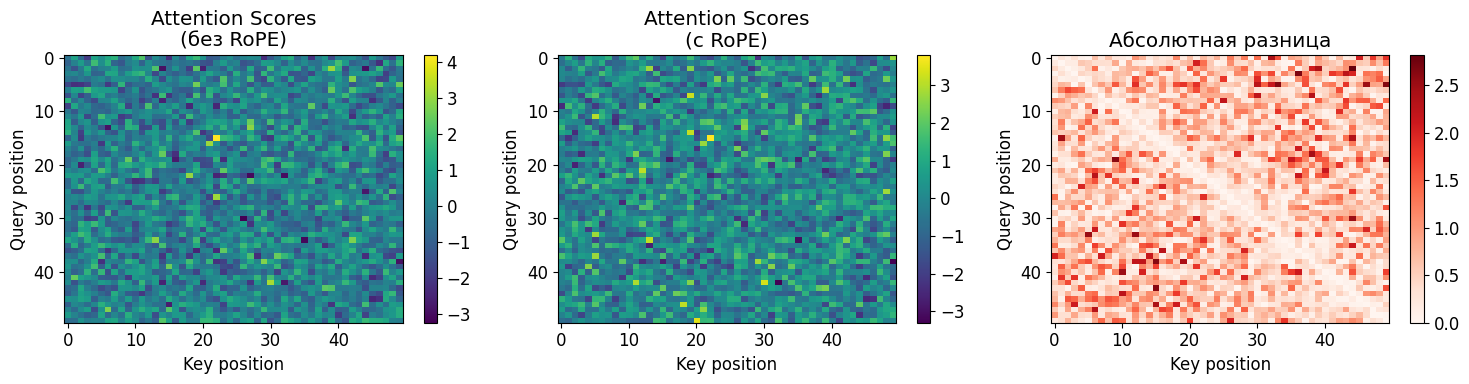

In [16]:
class RotaryPositionalEmbedding(nn.Module):
    """Rotary Position Embedding (RoPE)"""
    def __init__(self, d_model: int, max_len: int = 2048, base: int = 10000):
        super().__init__()
        self.d_model = d_model
        # Вычисляем частоты для каждой пары размерностей
        inv_freq = 1.0 / (base ** (torch.arange(0, d_model, 2).float() / d_model))
        self.register_buffer('inv_freq', inv_freq)
        # Предвычисляем для эффективности
        position = torch.arange(max_len).float()
        freqs = torch.outer(position, inv_freq)  # (max_len, d_model/2)
        # Создаем cos и sin для применения вращения
        emb = torch.cat([freqs, freqs], dim=-1)  # (max_len, d_model)
        self.register_buffer('cos_cached', emb.cos())
        self.register_buffer('sin_cached', emb.sin())
        
    def rotate_half(self, x: torch.Tensor) -> torch.Tensor:
        """Вращает половину размерностей для применения RoPE"""
        x1, x2 = x[..., :x.shape[-1]//2], x[..., x.shape[-1]//2:]
        return torch.cat([-x2, x1], dim=-1)
        
    def forward(self, q: torch.Tensor, k: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Применяет RoPE к query и key
        q, k: (batch, n_heads, seq_len, d_k)
        """
        seq_len = q.size(2)
        cos = self.cos_cached[:seq_len].unsqueeze(0).unsqueeze(0)  # (1, 1, seq_len, d_k)
        sin = self.sin_cached[:seq_len].unsqueeze(0).unsqueeze(0)
        # Применяем вращение: q * cos + rotate_half(q) * sin
        q_embed = q * cos + self.rotate_half(q) * sin
        k_embed = k * cos + self.rotate_half(k) * sin
        return q_embed, k_embed
        
# Демонстрация RoPE
d_model = 128
rope = RotaryPositionalEmbedding(d_model, max_len=100)
batch, n_heads, seq_len = 2, 8, 50
q = torch.randn(batch, n_heads, seq_len, d_model)
k = torch.randn(batch, n_heads, seq_len, d_model)
q_rot, k_rot = rope(q, k)
print(f"Query shape: {q.shape} -> {q_rot.shape}")
print(f"Key shape: {k.shape} -> {k_rot.shape}")

# Визуализация: сравниваем attention scores до и после RoPE

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Attention без RoPE

scores_no_rope = torch.matmul(q[0, 0], k[0, 0].transpose(-2, -1)) / math.sqrt(d_model)
im1 = axes[0].imshow(scores_no_rope.detach().numpy(), cmap='viridis', aspect='auto')
axes[0].set_title('Attention Scores\n(без RoPE)')
axes[0].set_xlabel('Key position')
axes[0].set_ylabel('Query position')
plt.colorbar(im1, ax=axes[0])

# Attention с RoPE
scores_with_rope = torch.matmul(q_rot[0, 0], k_rot[0, 0].transpose(-2, -1)) / math.sqrt(d_model)
im2 = axes[1].imshow(scores_with_rope.detach().numpy(), cmap='viridis', aspect='auto')
axes[1].set_title('Attention Scores\n(с RoPE)')
axes[1].set_xlabel('Key position')
axes[1].set_ylabel('Query position')
plt.colorbar(im2, ax=axes[1])

# Разница
diff = (scores_with_rope - scores_no_rope).abs()
im3 = axes[2].imshow(diff.detach().numpy(), cmap='Reds', aspect='auto')
axes[2].set_title('Абсолютная разница')
axes[2].set_xlabel('Key position')
axes[2].set_ylabel('Query position')
plt.colorbar(im3, ax=axes[2])
plt.tight_layout()
plt.savefig('rope_attention_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.10.5 Multimodal Rotary Position Embedding (M-RoPE)

**Мотивация**: Стандартный RoPE разработан для 1D последовательностей (текст). Для изображений нужно кодировать 2D структуру.
**Задача**: Для изображения размера $H \times W$, разбитого на патчи, нужно кодировать:
- Позицию по вертикали (row)
- Позицию по горизонтали (column)
- 
#### Архитектура M-RoPE

M-RoPE разбивает размерность эмбеддинга $d$ на три части:

$$
d = d_t + d_h + d_w
$$
где:
- $d_t$ - temporal/sequence dimension (для чисто последовательной информации)
- $d_h$ - height dimension (для вертикальной позиции)
- $d_w$ - width dimension (для горизонтальной позиции)Для каждой размерности применяется отдельный RoPE:
$$
\text{M-RoPE}(q) = [\text{RoPE}_t(q_t), \text{RoPE}_h(q_h, r), \text{RoPE}_w(q_w, c)]
$$
где $(r, c)$ - координаты патча (row, column).

#### Применение к изображениям

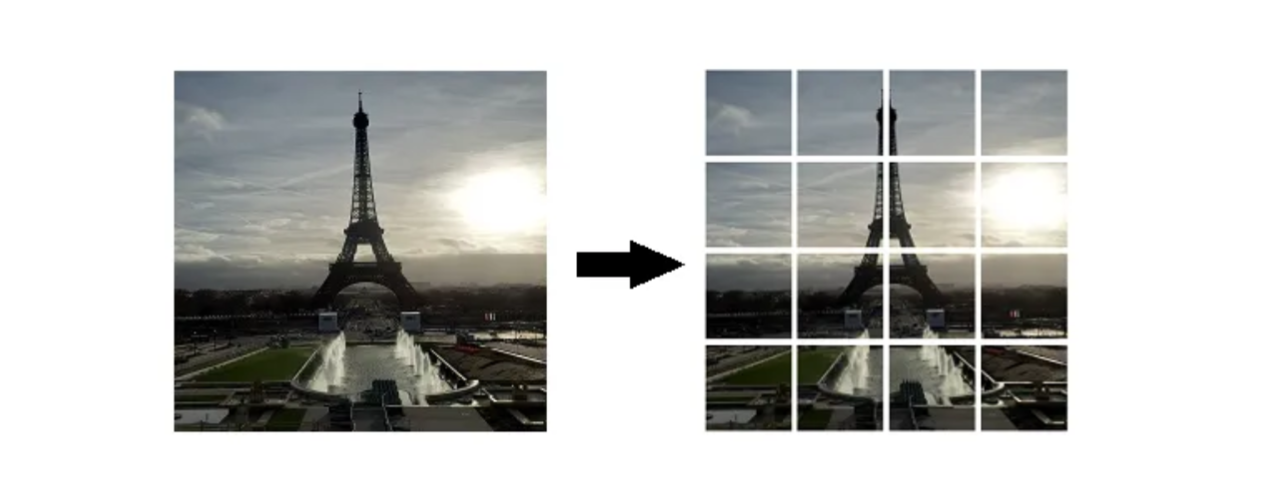

Для патча на позиции $(r, c)$ в изображении:

1. **Temporal component** ($d_t$ dims): Обычный RoPE по плоской последовательности
2. **Height component** ($d_h$ dims): RoPE с позицией $r$ (номер строки)
3. **Width component** ($d_w$ dims): RoPE с позицией $c$ (номер столбца)
4. **Пример** (Qwen-VL):
$d=4096$, разбиение $d_t : d_h : d_w = 1 : 1 : 2$
- $d_t = 1024$ dims для последовательности
- $d_h = 1024$ dims для высоты
- $d_w = 2048$ dims для ширины
  
#### Преимущества:

1. **2D Structure**: Естественно кодирует пространственную структуру изображения
2. **Aspect Ratio**: Разные изображения могут иметь разные $H$, $W$
3. **Resolution Flexibility**: Можно изменять разрешение при инференсе
4. **Relative Positions**: Сохраняет преимущества RoPE для относительных позиций
5. 
#### Используется в:
- **Qwen-VL** (Alibaba)
- **Qwen2-VL** - Multimodal LLMs с поддержкой изображений переменного разрешения
  

## Обучение трансформеров

---

### Encoder-only

Encoder обрабатывает последовательность **с двусторонним контекстом**: каждый токен
видит все остальные. Это не позволяет использовать авторегрессионный next-token prediction
как таргет (ответ тривиально доступен из контекста), поэтому применяется
**Masked Language Modeling (MLM)**. И это только для текстовых моделей! В CV все обучается на финальный лосс.

#### Masked Language Modeling

Пусть $X = (x_1, \ldots, x_n)$ — токены входной последовательности.
Случайно выбирается подмножество позиций $M \subset \{1,\ldots,n\}$, $|M| \approx 0.15\,n$.

Лосс считается **только по замаскированным позициям**:

$$\mathcal{L}_{\text{MLM}} = -\frac{1}{|M|}\sum_{i \in M} \log P_\theta(x_i \mid \tilde{X})$$

где $\tilde{X}$ — испорченная последовательность. В оригинальном BERT стратегия
замены для $i \in M$:

$$\tilde{x}_i = \begin{cases}
\texttt{[MASK]} & \text{с вероятностью } 0.8 \\
\text{случайный токен} & \text{с вероятностью } 0.1 \\
x_i & \text{с вероятностью } 0.1
\end{cases}$$

Зачем не маскировать всегда? Если модель всегда видит `[MASK]` при обучении, но
никогда — при инференсе, возникает **train/test mismatch**. Два нестандартных случая
(случайный токен / исходный токен) вынуждают модель поддерживать
контекстуальные представления **каждой** позиции, а не только явно замаскированных.

#### Attention в encoder

Матрица attention **полностью заполнена** (нет causal маски):

```
Attention mask (n=6, все видят всех):

     x1  x2  x3  x4  x5  x6
x1 [  1   1   1   1   1   1 ]
x2 [  1   1   1   1   1   1 ]
x3 [  1   1   1   1   1   1 ]
x4 [  1   1   1   1   1   1 ]
x5 [  1   1   1   1   1   1 ]
x6 [  1   1   1   1   1   1 ]
```

Padding-токены маскируются отдельно: для них столбцы (но не строки!) зануляются до softmax,
чтобы реальные токены не агрегировали информацию из паддинга.

#### Сложность инференса

Encoder прогоняет последовательность **один раз**: $O(n^2 d)$ — и получает финальные
эмбеддинги всех токенов одновременно. KV-cache не нужен. Это делает encoder
быстрым при инференсе, но непригодным для генерации.

---

### Encoder-Decoder

Архитектура для задач типа **sequence-to-sequence**: источник $X = (x_1,\ldots,x_n)$
и цель $Y = (y_1,\ldots,y_m)$ — последовательности разной длины и/или природы
(языки, модальности).

#### Структура forward pass

```
Encoder:   x1   x2   x3   x4   x5          ← полный двусторонний attention
            ↓    ↓    ↓    ↓    ↓
           h1   h2   h3   h4   h5           ← encoder states (memory)

Decoder:  <BOS> y1   y2   y3               ← вход (right-shifted таргет)
              ↓    ↓    ↓    ↓
         cross-attention ↑↑↑↑↑             ← decoder видит все h1..h5
              ↓    ↓    ↓    ↓
             y1   y2   y3  <EOS>            ← предсказания
```

#### Teacher forcing

При обучении на вход декодера подаётся **правильная** (ground-truth) сдвинутая
последовательность, а не предсказания модели — это называется **teacher forcing**:

$$\text{decoder input} = \langle\texttt{BOS}\rangle, y_1, y_2, \ldots, y_{m-1}$$
$$\text{target} = y_1, y_2, \ldots, y_{m-1}, \langle\texttt{EOS}\rangle$$

Лосс — авторегрессивный NLL по всем позициям выхода:

$$\mathcal{L}_{\text{S2S}} = -\frac{1}{m}\sum_{t=1}^{m} \log P_\theta\!\left(y_t \;\middle|\; y_{<t},\, H^{\text{enc}}\right)$$

где $H^{\text{enc}} = (h_1, \ldots, h_n)$ — выходы энкодера,
доступные декодеру через **cross-attention** на каждом слое:

$$\text{CrossAttn}(Q, K, V) = \text{softmax}\!\left(\frac{Q W^Q \cdot (H^{\text{enc}} W^K)^T}{\sqrt{d_k}}\right) H^{\text{enc}} W^V$$

$Q$ — из текущего состояния декодера, $K, V$ — из encoder states.

#### Attention маски в decoder

В декодере сосуществуют **два типа** масок:

```
Self-attention (causal):       Cross-attention:
      y1  y2  y3  y4                 h1  h2  h3  h4  h5
y1 [  1   0   0   0  ]    y1 [   1   1   1   1   1  ]
y2 [  1   1   0   0  ]    y2 [   1   1   1   1   1  ]
y3 [  1   1   1   0  ]    y3 [   1   1   1   1   1  ]
y4 [  1   1   1   1  ]    y4 [   1   1   1   1   1  ]
```

Self-attention — causal (нельзя смотреть вперёд по $Y$),
cross-attention — полная (decoder видит весь encoder output).

---

### Decoder-only

Decoder-only — наиболее распространённая архитектура современных LLM.
Единая последовательность является одновременно входом и таргетом.

#### Causal Language Modeling (CLM)

$$\mathcal{L}_{\text{CLM}} = -\frac{1}{T}\sum_{t=1}^{T} \log P_\theta(x_t \mid x_{<t})$$

Это точное вычисление $\log P_\theta(X)$ через chain rule:

$$\log P_\theta(x_1, \ldots, x_T) = \sum_{t=1}^{T} \log P_\theta(x_t \mid x_1, \ldots, x_{t-1})$$

**Ключевое отличие от encoder**: все $T$ предсказаний вычисляются **параллельно**
за один forward pass благодаря causal маске — модель видит только прошлое,
но обучается на всех позициях одновременно.

#### Causal (авторегрессивная) маска

$$M^{\text{causal}}_{ij} = \begin{cases} 0 & i \geq j \\ -\infty & i < j \end{cases}$$

то есть логиты attention перед softmax: $A = \text{softmax}\!\left(\dfrac{QK^T}{\sqrt{d_k}} + M^{\text{causal}}\right)$

```
Causal mask (T=6):

     x1   x2   x3   x4   x5   x6
x1 [  1    0    0    0    0    0 ]   ← x1 видит только себя
x2 [  1    1    0    0    0    0 ]
x3 [  1    1    1    0    0    0 ]
x4 [  1    1    1    1    0    0 ]
x5 [  1    1    1    1    1    0 ]
x6 [  1    1    1    1    1    1 ]   ← x6 видит всю историю
```

---

#### Префиксы переменной длины

На практике обучающий пример имеет вид `промпт + ответ`.
Задача модели — **генерировать ответ**, а не воспроизводить промпт,
поэтому лосс по токенам промпта не нужен и даже вреден
(промпт может содержать артефакты, специальные токены, системные инструкции).

##### Label masking

Для примера с промптом длины $p$ и ответом длины $a$ ($T = p + a$):

$$\mathcal{L} = -\frac{1}{a}\sum_{t=p+1}^{T} \log P_\theta(x_t \mid x_{<t})$$

В реализации это делается через маску лейблов: промпт-позиции получают `label = -100`,
которые `nn.CrossEntropyLoss` игнорирует автоматически.

```python
# Пример label masking для промпта длины 4 и ответа длины 4
#
# Последовательность:  [p1,  p2,  p3,  p4,  a1,  a2,  a3,  EOS]
# Input (ids):         [p1,  p2,  p3,  p4,  a1,  a2,  a3,  EOS]
# Labels:            [-100,-100,-100,-100,  a1,  a2,  a3,  EOS]
#                     ←── промпт (нет градиента) ──→←── ответ ──→

import torch
import torch.nn as nn

input_ids = torch.tensor([101, 202, 303, 404,  501, 502, 503, 2])
labels    = torch.tensor([-100,-100,-100,-100, 501, 502, 503, 2])

loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
# loss_fn автоматически игнорирует позиции с label=-100
```

При этом **causal mask не меняется**: промпт по-прежнему участвует в вычислении
attention (как контекст для ответа), просто не вносит вклад в лосс.

##### Батчинг и padding

При батчинге примеров разной длины последовательности дополняются до
$T_{\max} = \max_i T_i$ pad-токенами:

```python
# Батч из 3 примеров (pad_token_id = 0):
#
#   Пример 1: [p1 p2 a1 a2 a3  0  0  0]   T=5, pad=3
#   Пример 2: [p1 p2 p3 a1 a2 a3 a4  0]   T=7, pad=1
#   Пример 3: [p1 a1 a2  0  0  0  0  0]   T=3, pad=5

import torch

batch_input_ids = torch.tensor([
    [11, 12, 21, 22, 23,  0,  0,  0],
    [11, 12, 13, 21, 22, 23, 24,  0],
    [11, 21, 22,  0,  0,  0,  0,  0],
])

# attention_mask: 1 для реальных токенов, 0 для padding
attention_mask = (batch_input_ids != 0).long()

# labels: -100 для промпта И для padding
batch_labels = torch.tensor([
    [-100, -100,  21,  22,  23, -100, -100, -100],
    [-100, -100, -100,  21,  22,  23,  24, -100],
    [-100,  21,  22, -100, -100, -100, -100, -100],
])
```

Attention mask зануляет pad-столбцы, label mask зануляет и промпт-, и pad-позиции.

**Проблема**: padding создаёт wasted compute — модель обрабатывает пустые токены.
При большом разбросе длин это может тратить 30–50% вычислений впустую.

##### Sequence packing

Более эффективный подход: несколько примеров **конкатенируются** в одну длинную
последовательность. Attention mask становится блочно-диагональной,
запрещая «утечку» между документами:

```
Packed sequence: [p1 p2 a1 a2 | p1 p2 p3 a1 a2 | p1 a1 a2 a3]
                  ← doc 1 ──→   ←──── doc 2 ─────→  ←─ doc 3 ─→

Block-diagonal attention mask (causal внутри каждого документа):

       doc1        doc2           doc3
   [1  0  0  0 | 0  0  0  0  0 | 0  0  0  0]
   [1  1  0  0 | 0  0  0  0  0 | 0  0  0  0]
   [1  1  1  0 | 0  0  0  0  0 | 0  0  0  0]   ← doc1
   [1  1  1  1 | 0  0  0  0  0 | 0  0  0  0]
   ─────────────────────────────────────────
   [0  0  0  0 | 1  0  0  0  0 | 0  0  0  0]
   [0  0  0  0 | 1  1  0  0  0 | 0  0  0  0]
   [0  0  0  0 | 1  1  1  0  0 | 0  0  0  0]   ← doc2
   [0  0  0  0 | 1  1  1  1  0 | 0  0  0  0]
   [0  0  0  0 | 1  1  1  1  1 | 0  0  0  0]
   ─────────────────────────────────────────
   [0  0  0  0 | 0  0  0  0  0 | 1  0  0  0]
   [0  0  0  0 | 0  0  0  0  0 | 1  1  0  0]   ← doc3
   [0  0  0  0 | 0  0  0  0  0 | 1  1  1  0]
   [0  0  0  0 | 0  0  0  0  0 | 1  1  1  1]
```

```python
import torch

def build_packing_mask(doc_lengths: list[int]) -> torch.Tensor:
    """Строит block-diagonal causal attention mask для packed sequence."""
    total = sum(doc_lengths)
    mask = torch.zeros(total, total)

    offset = 0
    for length in doc_lengths:
        # Causal mask внутри документа
        block = torch.tril(torch.ones(length, length))
        mask[offset:offset+length, offset:offset+length] = block
        offset += length

    return mask

# Пример: 3 документа длиной 4, 5, 4
mask = build_packing_mask([4, 5, 4])
print(f"Packed sequence length: {mask.shape[0]}")
print(f"Non-zero elements: {mask.sum().item():.0f} / {mask.numel()} "
      f"({mask.mean().item()*100:.1f}%)")
```

Внутри каждого документа маска остаётся **causal** (нижнетреугольной).
Документы полностью изолированы: токены из doc2 не могут видеть токены из doc1
и наоборот.

> **Важно:** наивная конкатенация без блочной маски приводит к тому, что
> начало второго документа «видит» конец первого — это **data leakage**,
> ухудшающий качество и нарушающий i.i.d. предположение при обучении.
> Sequence packing с корректной маской поддерживается, например, через
> `attention_mask` в HuggingFace при использовании Flash Attention 2.


## Часть 2.4: Сложность инференса энкодера и декодера. KV-cache

### Теория: Вычислительная сложность attention механизма

#### Базовая формула attention

Напомним, что attention вычисляется как:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

где:
- $Q \in \mathbb{R}^{n \times d_k}$ — матрица запросов (queries)
- $K \in \mathbb{R}^{m \times d_k}$ — матрица ключей (keys)  
- $V \in \mathbb{R}^{m \times d_v}$ — матрица значений (values)
- $n$ — длина последовательности запросов
- $m$ — длина последовательности ключей/значений
- $d_k$ — размерность ключей/запросов
- $d_v$ — размерность значений

#### Сложность операций

**Вычисление $QK^T$:**
- Размерность результата: $n \times m$
- Количество операций: $\mathcal{O}(n \cdot m \cdot d_k)$

**Применение softmax:**
- Для каждой из $n$ строк применяем softmax по $m$ элементам
- Сложность: $\mathcal{O}(n \cdot m)$

**Умножение на $V$:**
- $(n \times m) \times (m \times d_v) = n \times d_v$
- Количество операций: $\mathcal{O}(n \cdot m \cdot d_v)$

**Итоговая сложность одного attention слоя:** $\mathcal{O}(n \cdot m \cdot d)$, где $d = \max(d_k, d_v)$.

Для self-attention (когда $n = m = L$ — длина последовательности):

$$\boxed{\text{Complexity} = \mathcal{O}(L^2 \cdot d)}$$

Это **квадратичная** зависимость от длины последовательности!

### Проблема автрегрессивной генерации

#### Encoder-only модели (BERT, ViT)

При инференсе encoder обрабатывает всю последовательность **за один проход**:

```python
# Псевдокод для encoder inference
def encoder_inference(input_sequence):
    # input_sequence: [batch_size, seq_len, d_model]
    
    # Один проход через все слои
    hidden_states = input_sequence
    for layer in encoder_layers:
        hidden_states = layer(hidden_states)
    
    return hidden_states
```

**Сложность инференса encoder:**
- Длина последовательности: $L$
- Количество слоев: $N$
- Размерность модели: $d$

$$\boxed{\text{Total complexity} = \mathcal{O}(N \cdot L^2 \cdot d)}$$

**Время инференса:** константа относительно генерации — один forward pass.

#### Decoder-only модели (GPT, автрегрессивная генерация)

При генерации decoder работает **итеративно**, генерируя по одному токену:

```python
# Псевдокод для naive decoder inference
def naive_decoder_inference(prompt_tokens, max_length):
    generated = prompt_tokens.copy()
    
    for step in range(max_length):
        # На каждом шаге обрабатываем ВСЮ последовательность заново!
        logits = decoder(generated)  # [batch_size, current_len, vocab_size]
        next_token = sample(logits[:, -1, :])  # Берем только последний токен
        generated.append(next_token)
    
    return generated
```

**Проблема:** На каждом шаге генерации мы пересчитываем attention для **всех предыдущих токенов**, хотя их представления не изменились!

**Сложность генерации $T$ токенов (naive approach):**

На шаге $t$ мы обрабатываем последовательность длины $L_0 + t$ (где $L_0$ — длина промпта):

$$\text{Step } t: \mathcal{O}(N \cdot (L_0 + t)^2 \cdot d)$$

Суммарная сложность:

$$\sum_{t=1}^{T} \mathcal{O}(N \cdot (L_0 + t)^2 \cdot d) = \mathcal{O}(N \cdot T^3 \cdot d)$$

Это **кубическая** сложность по количеству генерируемых токенов! 🔥

### KV-Cache: оптимизация автрегрессионного инференса

#### Ключевое наблюдение

В автрегрессивной генерации новый токен $x_t$ может **только смотреть на предыдущие** токены $x_1, \ldots, x_{t-1}$ из-за causal маски.

Значит, ключи $K$ и значения $V$ для токенов $x_1, \ldots, x_{t-1}$ **не меняются** при добавлении нового токена!

#### Математическая формализация

На шаге $t$ мы вычисляем attention для нового токена:

$$Q_t = W_Q \cdot h_t, \quad h_t = \text{embedding}(x_t)$$

Для предыдущих токенов мы **уже вычислили** на предыдущих шагах:

$$K_{1:t-1} = [K_1, K_2, \ldots, K_{t-1}], \quad V_{1:t-1} = [V_1, V_2, \ldots, V_{t-1}]$$

На текущем шаге нам нужно только:

$$K_t = W_K \cdot h_t, \quad V_t = W_V \cdot h_t$$

И добавить их к кешу:

$$K_{1:t} = [K_{1:t-1}, K_t], \quad V_{1:t} = [V_{1:t-1}, V_t]$$

Теперь attention для токена $t$:

$$\text{Attention}_t = \text{softmax}\left(\frac{Q_t \cdot K_{1:t}^T}{\sqrt{d_k}}\right) \cdot V_{1:t}$$

**Важно:** Мы вычисляем $Q_t$ только для **одного** нового токена, а $K_{1:t-1}$ и $V_{1:t-1}$ берем из кеша!

#### Структура KV-cache

KV-cache хранит для каждого слоя и каждой головы attention:

$$\text{KV-cache shape} = [\text{layers}, \text{heads}, \text{seq\_length}, d_k]$$

Для модели с:
- $N = 32$ слоями
- $H = 32$ головами
- $d_k = 128$ (размерность на голову)
- $L = 2048$ (максимальная длина контекста)
- FP16 (2 байта на число)

Размер одного cache (K или V):

$$32 \times 32 \times 2048 \times 128 \times 2 = 536\text{ MB}$$

Для обоих (K и V): **~1 GB** на одну последовательность.

Для батча размера $B = 32$: **~32 GB** только на KV-cache!

### Сложность инференса с KV-cache

#### Анализ сложности

**Шаг 1: Prefill (обработка промпта)**

Промпт длины $L_0$ обрабатывается за один проход:

$$\text{Prefill complexity} = \mathcal{O}(N \cdot L_0^2 \cdot d)$$

На этом шаге заполняется начальный KV-cache.

**Шаг 2: Декодирование (генерация токенов)**

На каждом шаге $t$ генерации:

1. Вычисляем $Q_t$ для нового токена: $\mathcal{O}(d^2)$
2. Вычисляем attention с кешем длины $L_0 + t - 1$: $\mathcal{O}((L_0 + t) \cdot d)$
3. Обновляем кеш: $\mathcal{O}(d)$

Для одного слоя: $\mathcal{O}((L_0 + t) \cdot d)$

Для $N$ слоев: $\mathcal{O}(N \cdot (L_0 + t) \cdot d)$

Генерация $T$ токенов:

$$\sum_{t=1}^{T} \mathcal{O}(N \cdot (L_0 + t) \cdot d) = \mathcal{O}(N \cdot T \cdot L_0 \cdot d + N \cdot T^2 \cdot d)$$

Если $T \ll L_0$:

$$\boxed{\text{Decoding complexity} \approx \mathcal{O}(N \cdot T \cdot L_0 \cdot d)}$$

Это **линейная** сложность по $T$ (вместо кубической)!

#### Сравнение: с кешем vs без кеша

| Метод | Prefill | Decoding (T токенов) | Total |
|-------|---------|---------------------|-------|
| Без кеша | $\mathcal{O}(N L_0^2 d)$ | $\mathcal{O}(N T^3 d)$ | $\mathcal{O}(N T^3 d)$ |
| С кешем | $\mathcal{O}(N L_0^2 d)$ | $\mathcal{O}(N T L_0 d)$ | $\mathcal{O}(N L_0^2 d + N T L_0 d)$ |

**Пример:** $L_0 = 512$, $T = 512$, $N = 32$, $d = 4096$

- Без кеша: $32 \times 512^3 \times 4096 \approx 1.7 \times 10^{13}$ ops
- С кешем: $32 \times 512^2 \times 4096 + 32 \times 512 \times 512 \times 4096 \approx 6.9 \times 10^{10}$ ops

**Ускорение: ~250x** 🚀




In [17]:
### Практическая реализация KV-cache
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttentionWithCache(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def split_heads(self, x):
        # x: [batch, seq_len, d_model]
        batch_size, seq_len, _ = x.shape
        # Разбиваем на головы
        x = x.view(batch_size, seq_len, self.num_heads, self.d_k)
        # Переставляем: [batch, num_heads, seq_len, d_k]
        return x.transpose(1, 2)
    
    def forward(self, query, key, value, cache=None, use_cache=False):
        """
        Args:
            query: [batch, 1, d_model] для генерации или [batch, seq_len, d_model] для prefill
            key: [batch, seq_len, d_model]
            value: [batch, seq_len, d_model]
            cache: dict с ключами 'k' и 'v' - предыдущие ключи и значения
            use_cache: bool - использовать ли кеш
        
        Returns:
            output: [batch, query_len, d_model]
            new_cache: dict с обновленным кешем (если use_cache=True)
        """
        batch_size = query.shape[0]
        query_len = query.shape[1]
        
        # Вычисляем Q, K, V для текущего токена
        Q = self.W_q(query)  # [batch, query_len, d_model]
        K = self.W_k(key)    # [batch, key_len, d_model]
        V = self.W_v(value)  # [batch, key_len, d_model]
        
        # Если используем кеш и он не пустой
        if use_cache and cache is not None:
            # Достаем предыдущие K и V из кеша
            cached_K = cache['k']  # [batch, num_heads, prev_len, d_k]
            cached_V = cache['v']  # [batch, num_heads, prev_len, d_k]
            
            # Разбиваем новые K и V на головы
            K = self.split_heads(K)  # [batch, num_heads, key_len, d_k]
            V = self.split_heads(V)  # [batch, num_heads, key_len, d_k]
            
            # Конкатенируем с кешем по размерности длины
            K = torch.cat([cached_K, K], dim=2)  # [batch, num_heads, prev_len+key_len, d_k]
            V = torch.cat([cached_V, V], dim=2)  # [batch, num_heads, prev_len+key_len, d_k]
        else:
            # Если кеша нет - просто разбиваем на головы
            K = self.split_heads(K)
            V = self.split_heads(V)
        
        Q = self.split_heads(Q)  # [batch, num_heads, query_len, d_k]
        
        # Вычисляем attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        # scores: [batch, num_heads, query_len, key_len]
        
        attention_weights = F.softmax(scores, dim=-1)
        
        # Применяем attention к V
        attention_output = torch.matmul(attention_weights, V)
        # [batch, num_heads, query_len, d_k]
        
        # Объединяем головы
        attention_output = attention_output.transpose(1, 2).contiguous()
        # [batch, query_len, num_heads, d_k]
        attention_output = attention_output.view(batch_size, query_len, self.d_model)
        
        # Финальная проекция
        output = self.W_o(attention_output)
        
        # Обновляем кеш
        new_cache = None
        if use_cache:
            new_cache = {'k': K, 'v': V}
        
        return output, new_cache


class TransformerDecoderLayerWithCache(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttentionWithCache(d_model, num_heads)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, cache=None, use_cache=False):
        # Self-attention с кешем
        attn_output, new_cache = self.self_attn(
            query=x, key=x, value=x,
            cache=cache, use_cache=use_cache
        )
        x = self.norm1(x + self.dropout(attn_output))
        
        # Feed-forward
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        
        return x, new_cache


def generate_with_cache(model, input_ids, max_length=50, temperature=1.0):
    """
    Генерация текста с использованием KV-cache
    
    Args:
        model: Transformer decoder модель
        input_ids: [batch_size, seq_len] - начальная последовательность
        max_length: максимальная длина генерации
        temperature: температура для сэмплирования
    """
    batch_size = input_ids.shape[0]
    device = input_ids.device
    
    # Инициализируем кеш для каждого слоя
    # В реальных моделях кеш хранится внутри слоев
    caches = [None] * len(model.layers)
    
    generated = input_ids.clone()
    
    # Prefill: обрабатываем начальную последовательность
    print(f"Prefill: processing {input_ids.shape[1]} tokens...")
    with torch.no_grad():
        x = model.embed(input_ids)
        
        for layer_idx, layer in enumerate(model.layers):
            x, caches[layer_idx] = layer(x, cache=None, use_cache=True)
        
        logits = model.head(x[:, -1:, :])  # Берем только последний токен
    
    # Декодирование: генерируем по одному токену
    print(f"Decoding: generating {max_length - input_ids.shape[1]} tokens...")
    for step in range(max_length - input_ids.shape[1]):
        # Сэмплируем следующий токен
        probs = F.softmax(logits / temperature, dim=-1)
        next_token = torch.multinomial(probs.squeeze(1), num_samples=1)
        
        generated = torch.cat([generated, next_token], dim=1)
        
        # Обрабатываем ТОЛЬКО новый токен
        with torch.no_grad():
            x = model.embed(next_token)
            
            for layer_idx, layer in enumerate(model.layers):
                # Используем кеш из предыдущего шага
                x, caches[layer_idx] = layer(
                    x, cache=caches[layer_idx], use_cache=True
                )
            
            logits = model.head(x)
        
        if step % 10 == 0:
            print(f"  Generated {step} tokens, cache size: {caches[0]['k'].shape}")
    
    return generated


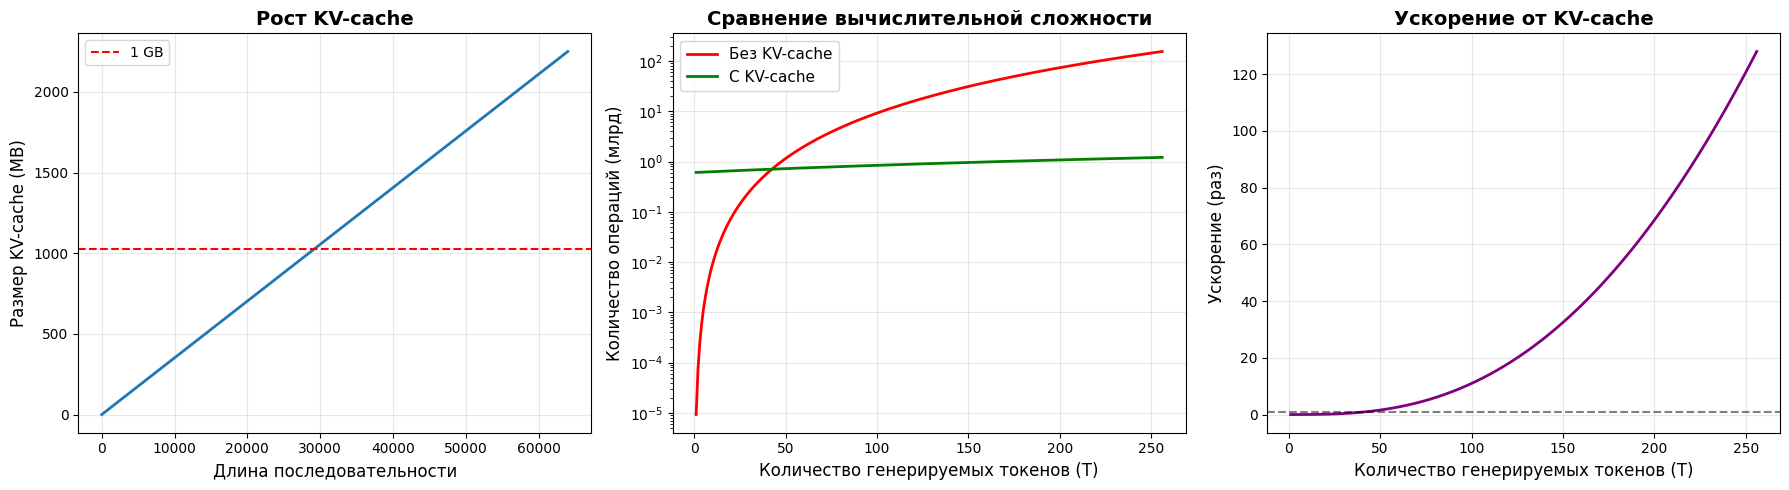

In [28]:
### Визуализация работы KV-cache

import matplotlib.pyplot as plt
import numpy as np

def visualize_kv_cache_growth():
    """
    Визуализация роста KV-cache и сравнение сложности
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Рост размера кеша
    seq_lengths = np.arange(1, 64000)
    
    # Параметры модели (пример: GPT-3 small)
    n_layers = 12
    n_heads = 12
    d_k = 64
    bytes_per_element = 2  # FP16
    
    # Размер кеша для K и V
    cache_size_mb = (seq_lengths * n_layers * n_heads * d_k * bytes_per_element * 2) / (1024 ** 2)
    
    axes[0].plot(seq_lengths, cache_size_mb, linewidth=2)
    axes[0].set_xlabel('Длина последовательности', fontsize=12)
    axes[0].set_ylabel('Размер KV-cache (MB)', fontsize=12)
    axes[0].set_title('Рост KV-cache', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=1024, color='r', linestyle='--', label='1 GB')
    axes[0].legend()
    
    # 2. Сравнение количества операций
    T = np.arange(1, 257)  # Количество генерируемых токенов
    L0 = 256  # Длина промпта
    N = 12
    d = 768
    
    # Без кеша: O(N * T^3 * d)
    ops_no_cache = N * (T ** 3) * d / 1e9  # В миллиардах операций
    
    # С кешем: O(N * L0^2 * d) + O(N * T * L0 * d)
    ops_with_cache = (N * (L0 ** 2) * d + N * T * L0 * d) / 1e9
    
    axes[1].plot(T, ops_no_cache, label='Без KV-cache', linewidth=2, color='red')
    axes[1].plot(T, ops_with_cache, label='С KV-cache', linewidth=2, color='green')
    axes[1].set_xlabel('Количество генерируемых токенов (T)', fontsize=12)
    axes[1].set_ylabel('Количество операций (млрд)', fontsize=12)
    axes[1].set_title('Сравнение вычислительной сложности', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_yscale('log')
    
    # 3. Ускорение от использования кеша
    speedup = ops_no_cache / ops_with_cache
    
    axes[2].plot(T, speedup, linewidth=2, color='purple')
    axes[2].set_xlabel('Количество генерируемых токенов (T)', fontsize=12)
    axes[2].set_ylabel('Ускорение (раз)', fontsize=12)
    axes[2].set_title('Ускорение от KV-cache', fontsize=14, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=1, color='black', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('kv_cache_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_kv_cache_growth()

## Часть 3: Архитектуры трансформеров в CV

### 3.1 BERT как текстовая модель

#### Архитектура BERT

**BERT (Bidirectional Encoder Representations from Transformers)** — encoder-only архитектура для NLP задач.

**Ключевые компоненты:**

1. **Embedding слой:**
   - Token embeddings (WordPiece)
   - Position embeddings (learned, до 512 позиций)
   - Segment embeddings (для задач с парой предложений)

$$\text{Input} = \text{TokenEmb} + \text{PositionEmb} + \text{SegmentEmb}$$

2. **Transformer Encoder:**
   - $N = 12$ слоев (BERT-Base) или $N = 24$ (BERT-Large)
   - Multi-head self-attention с $H = 12$ или $H = 16$ головами
   - Feed-forward network с промежуточной размерностью $d_{ff} = 4 \times d_{model}$

3. **[CLS] токен:**
   - Специальный токен в начале последовательности
   - Его финальное представление используется для **агрегации всей последовательности**

**Зачем нужен [CLS]?**

BERT обучался на двух задачах:

1. **Masked Language Model (MLM):** предсказание замаскированных токенов
2. **Next Sentence Prediction (NSP):** предсказание, является ли второе предложение продолжением первого

Для NSP нужно представление **всей последовательности**. [CLS] токен:

- Имеет доступ ко всем остальным токенам через self-attention
- Аккумулирует контекст всей последовательности
- Используется как вход для классификатора

$$\text{Sentence representation} = \text{BERTEncoder}(\text{tokens})_{[\text{CLS}]}$$

#### Обучение BERT

**Masked Language Model (MLM):**

1. Случайно выбираем 15% токенов
2. Из них: 80% заменяем на [MASK], 10% на случайный токен, 10% оставляем
3. Задача: предсказать оригинальный токен

$$\mathcal{L}_{\text{MLM}} = -\sum_{i \in \text{masked}} \log P(x_i | \mathbf{x}_{\backslash i})$$

где $\mathbf{x}_{\backslash i}$ — последовательность с замаскированным $i$-м токеном.

**Next Sentence Prediction (NSP):**

Бинарная классификация: IsNext или NotNext

$$\mathcal{L}_{\text{NSP}} = -\log P(\text{label} | [\text{CLS}])$$

**Итоговая функция потерь:**

$$\mathcal{L} = \mathcal{L}_{\text{MLM}} + \mathcal{L}_{\text{NSP}}$$

---

### 3.2 Vision Transformer (ViT)

#### От текста к изображениям: ключевые изменения

**Проблема:** BERT работает с дискретными токенами (слова). Изображения — непрерывные пиксели.

**Решение ViT:** разбить изображение на **патчи** и рассматривать их как токены!

#### Нарезка изображения на патчи

Изображение размера $H \times W \times C$ разбивается на последовательность патчей:

$$\text{Количество патчей} = N = \frac{H \times W}{P^2}$$

где $P$ — размер патча (обычно 16 или 32).

Каждый патч векторизуется:

$$\text{Patch size} = P \times P \times C$$

**Пример:** Изображение $224 \times 224 \times 3$ с патчами $16 \times 16$:

$$N = \frac{224 \times 224}{16 \times 16} = \frac{224}{16} \times \frac{224}{16} = 14 \times 14 = 196 \text{ патчей}$$

Каждый патч: $16 \times 16 \times 3 = 768$ значений.

#### Архитектура ViT

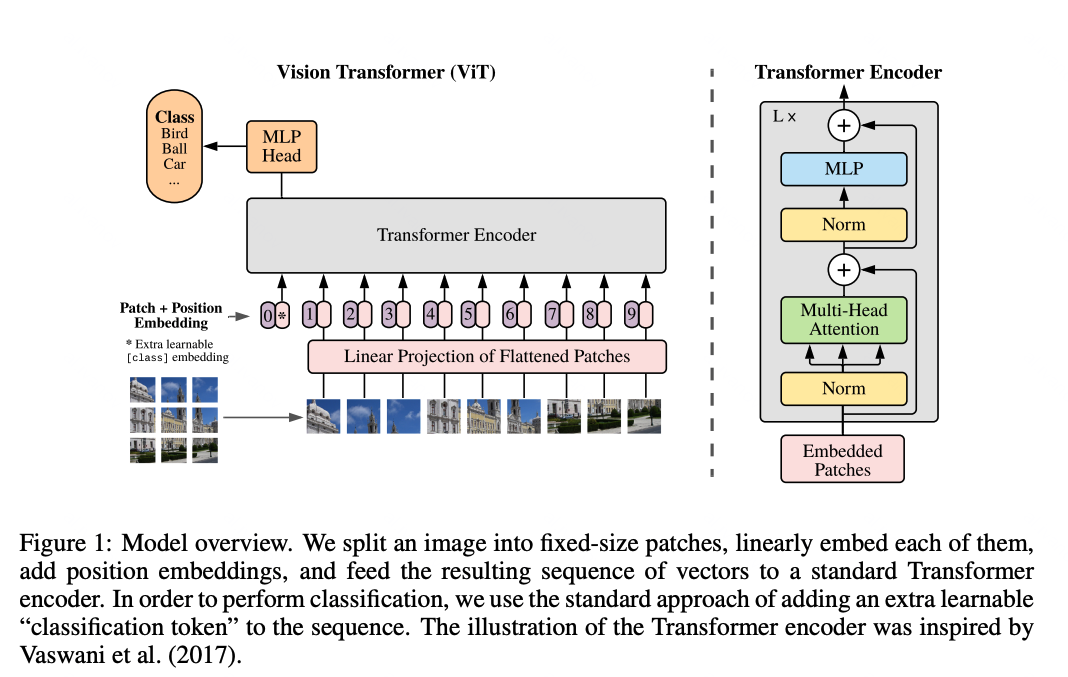

**Шаги обработки:**

1. **Patch Embedding:**

Линейная проекция векторизованных патчей в пространство размерности $d$:

$$E_0 = [x_1^p; x_2^p; \ldots; x_N^p] \mathbf{W}_p + \mathbf{b}$$

где $x_i^p \in \mathbb{R}^{P^2 C}$ — $i$-й патч, $\mathbf{W}_p \in \mathbb{R}^{(P^2 C) \times d}$ — матрица проекции.

2. **CLS Token:**

Добавляем learnable [CLS] токен в начало:

$$\mathbf{z}_0 = [\mathbf{x}_{\text{cls}}; E_0^1; E_0^2; \ldots; E_0^N]$$

3. **Position Embeddings:**

Добавляем learnable позиционные эмбеддинги:

$$\mathbf{z}_0 = \mathbf{z}_0 + \mathbf{E}_{\text{pos}}$$

где $\mathbf{E}_{\text{pos}} \in \mathbb{R}^{(N+1) \times d}$ — learnable параметры.

**Важно:** В ViT используются **1D** позиционные эмбеддинги, а не 2D! Авторы экспериментировали с 2D (отдельные эмбеддинги для строк и столбцов), но не обнаружили улучшения.

4. **Transformer Encoder:**

Стандартный Transformer encoder с $L$ слоями:

$$\mathbf{z}_\ell = \text{TransformerBlock}(\mathbf{z}_{\ell-1}), \quad \ell = 1, \ldots, L$$

5. **Classification Head:**

MLP head на выходе [CLS] токена:

$$y = \text{MLP}(\text{LayerNorm}(\mathbf{z}_L^0))$$

где $\mathbf{z}_L^0$ — представление [CLS] токена после последнего слоя.

#### Варианты Position Embeddings в ViT

**1. Learned 1D Position Embeddings (используется в ViT):**

Каждой позиции $i = 0, 1, \ldots, N$ соответствует learnable вектор $\mathbf{p}_i \in \mathbb{R}^d$:

$$\mathbf{z}_i^{(0)} = \mathbf{e}_i + \mathbf{p}_i$$

**2. Learned 2D Position Embeddings:**

Для патча на позиции $(h, w)$ в сетке:

$$\mathbf{p}_{h,w} = \mathbf{p}_h^{\text{row}} + \mathbf{p}_w^{\text{col}}$$

где $\mathbf{p}_h^{\text{row}}, \mathbf{p}_w^{\text{col}} \in \mathbb{R}^d$ — learnable параметры.

**3. Sinusoidal Position Embeddings (как в Attention is All You Need):**

$$\text{PE}(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d}}\right)$$
$$\text{PE}(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

**4. Relative Position Embeddings:**

Вместо абсолютной позиции учитывают **относительное** расстояние между патчами.

**Результаты экспериментов (из статьи ViT):**

| Тип Position Embeddings | ImageNet Top-1 Accuracy |
|-------------------------|------------------------|
| No position embeddings | 61.3% |
| 1D Learned | **77.9%** |
| 2D Learned | 77.7% |
| Sinusoidal | 77.3% |

Вывод: **learned 1D позиционные эмбеддинги оказались лучшими**, несмотря на отсутствие явного учета 2D структуры.

#### ViT-Base, ViT-Large, ViT-Huge: параметризация

Семейство ViT определяется тремя параметрами:

| Модель | Layers (L) | Hidden size (d) | MLP size | Heads (H) | Params |
|--------|----------|---------------|---------|----------|--------|
| **ViT-Base/16** | 12 | 768 | 3072 | 12 | **86M** |
| **ViT-Large/16** | 24 | 1024 | 4096 | 16 | **307M** |
| **ViT-Huge/14** | 32 | 1280 | 5120 | 16 | **632M** |

Обозначение `/16` и `/14` — размер патча.

**Формула для подсчета параметров:**

Основные компоненты:

1. **Patch embedding:** $P^2 C \times d$
2. **Position embeddings:** $(N + 1) \times d$
3. **Transformer encoder слой:**
   - QKV проекции: $3 \times d \times d$
   - Output проекция: $d \times d$
   - MLP: $d \times d_{\text{mlp}} + d_{\text{mlp}} \times d$
4. **Classification head:** $d \times \text{num\_classes}$

Для ViT-Base/16 на ImageNet-1K:

$$\begin{align}
\text{Params} &\approx L \times [3d^2 + d^2 + 2d \cdot d_{\text{mlp}}] + P^2Cd + (N+1)d \\
&= 12 \times [3 \times 768^2 + 768^2 + 2 \times 768 \times 3072] + 768 \times 768 + 197 \times 768 \\
&\approx 86M
\end{align}$$


In [19]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    """
    Преобразование изображения в последовательность patch embeddings
    """
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        
        # Используем Conv2D для эффективной реализации patch projection
        # Kernel size = stride = patch_size
        self.proj = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )
    
    def forward(self, x):
        # x: [B, C, H, W]
        x = self.proj(x)  # [B, embed_dim, H/P, W/P]
        x = x.flatten(2)  # [B, embed_dim, n_patches]
        x = x.transpose(1, 2)  # [B, n_patches, embed_dim]
        return x


class VisionTransformer(nn.Module):
    """
    Vision Transformer (ViT) архитектура
    """
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_channels=3,
        num_classes=1000,
        embed_dim=768,
        depth=12,
        num_heads=12,
        mlp_ratio=4.0,
        dropout=0.1
    ):
        super().__init__()
        
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.n_patches
        
        # CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        
        # Position embeddings для (CLS + patches)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=dropout)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True  # Pre-LayerNorm (как в оригинальном ViT)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        
        # Classification head
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        
        # Инициализация
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
    
    def forward(self, x):
        # x: [B, C, H, W]
        B = x.shape[0]
        
        # Patch embedding
        x = self.patch_embed(x)  # [B, n_patches, embed_dim]
        
        # Добавляем CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)  # [B, 1, embed_dim]
        x = torch.cat([cls_tokens, x], dim=1)  # [B, n_patches+1, embed_dim]
        
        # Добавляем position embeddings
        x = x + self.pos_embed
        x = self.pos_drop(x)
        
        # Transformer encoder
        x = self.transformer(x)
        
        # Classification: используем CLS token
        x = self.norm(x[:, 0])  # [B, embed_dim]
        x = self.head(x)  # [B, num_classes]
        
        return x


# Создание моделей разных размеров
def vit_base_patch16_224(num_classes=1000):
    return VisionTransformer(
        img_size=224, patch_size=16,
        embed_dim=768, depth=12, num_heads=12,
        num_classes=num_classes
    )

def vit_large_patch16_224(num_classes=1000):
    return VisionTransformer(
        img_size=224, patch_size=16,
        embed_dim=1024, depth=24, num_heads=16,
        num_classes=num_classes
    )

def vit_huge_patch14_224(num_classes=1000):
    return VisionTransformer(
        img_size=224, patch_size=14,
        embed_dim=1280, depth=32, num_heads=16,
        num_classes=num_classes
    )

# Пример
model = vit_base_patch16_224(num_classes=1000)
x = torch.randn(2, 3, 224, 224)
output = model(x)
print(f"Output shape: {output.shape}")  # [2, 1000]

# Подсчет параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params / 1e6:.2f}M")
print(f"Trainable parameters: {trainable_params / 1e6:.2f}M")


/Users/al.ivanov/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Output shape: torch.Size([2, 1000])
Total parameters: 86.57M
Trainable parameters: 86.57M


#### Обучение ViT vs ResNet-50: сравнение

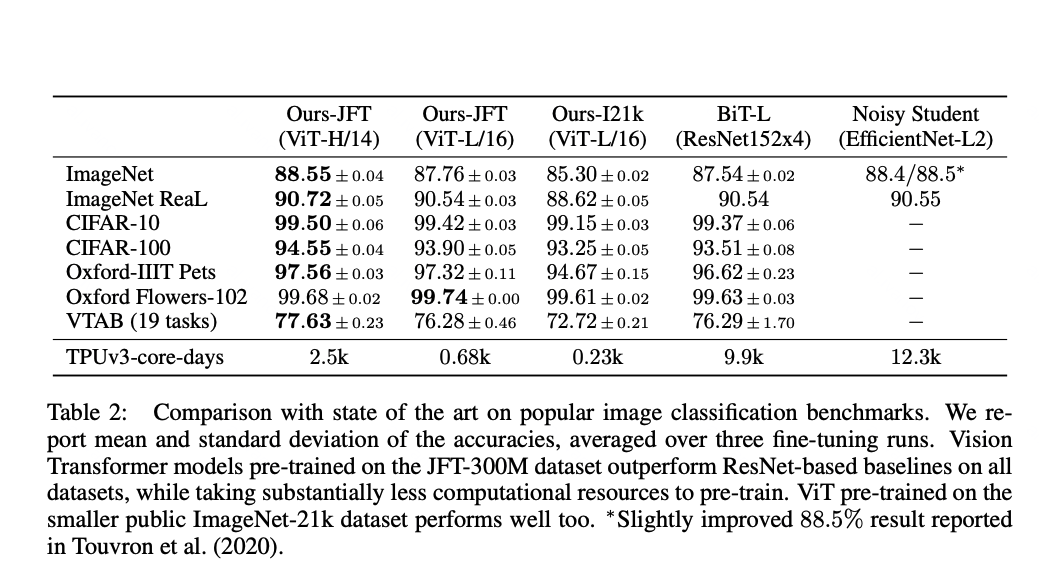

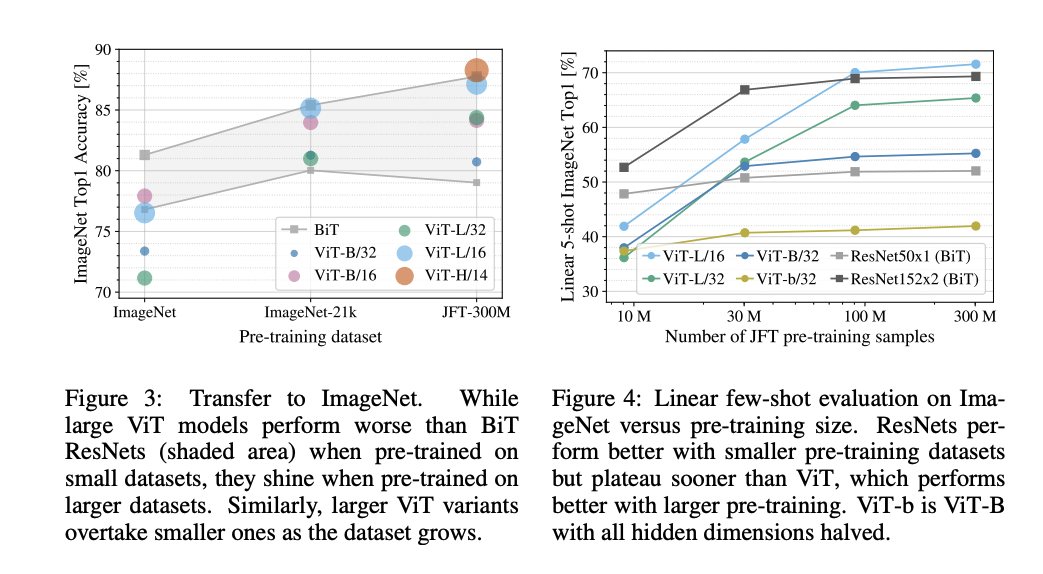

**Ключевые выводы из оригинальной статьи:**

1. **Data Efficiency:**

| Model | Pre-training Dataset | ImageNet Top-1 |
|-------|---------------------|----------------|
| ResNet-50 | ImageNet-1K (1.3M) | 76.5% |
| ViT-Base/16 | ImageNet-1K (1.3M) | **77.9%** |
| ViT-Base/16 | ImageNet-21K (14M) | 81.5% |
| ViT-Base/16 | JFT-300M (300M) | **84.5%** |

**Важно:** На малых датасетах (ImageNet-1K) ViT сравним с ResNet, но на больших (JFT-300M) значительно превосходит.

2. **Training Time:**

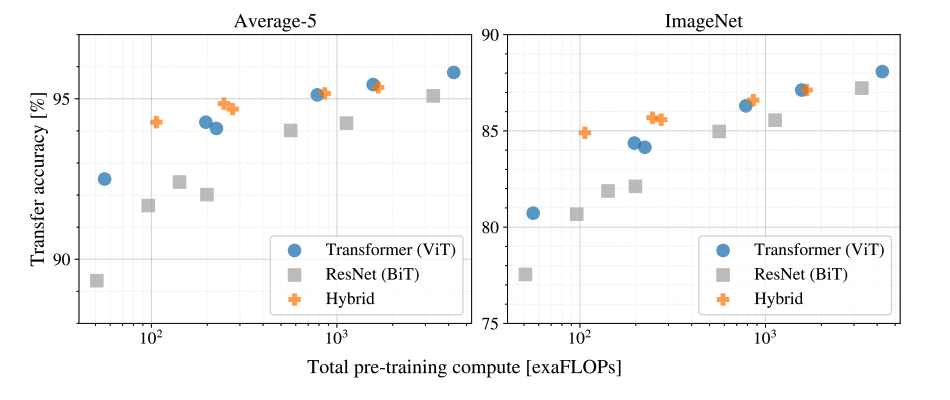

Из статьи (Table 6):

| Model | Hardware | Pre-training Time | Total TPU-days |
|-------|----------|------------------|----------------|
| ResNet-50 (BiT-L) | TPUv3 | ~30 days | **~9000** |
| ViT-Base/16 | TPUv3 | ~7 days | 2.5k |
| ViT-Large/16 | TPUv3 | ~30 days | 10k |

Для сравнимого качества ViT требует **меньше** вычислений.

3. **Inference Speed:**

| Model | Throughput (img/sec on TPUv3) | FLOPs |
|-------|-------------------------------|-------|
| ResNet-50 | ~1800 | 4.1G |
| ViT-Base/16 | **~2100** | 17.6G |

ViT имеет больше FLOPs, но **более эффективно параллелизуется** на TPU/GPU из-за матричных операций.


---

### 3.3 Swin Transformer

#### Мотивация: проблемы ViT

**Проблема 1: Фиксированный размер патча**

ViT использует патчи одного размера (16×16) на всех уровнях. Но в компьютерном зрении полезна **иерархическая** структура, как в CNN:

- Ранние слои — мелкие детали (edges, textures)
- Поздние слои — крупные объекты (shapes, objects)

**Проблема 2: Квадратичная сложность**

Self-attention в ViT: $\mathcal{O}(N^2)$, где $N$ — число патчей.

Для изображения $224 \times 224$ с патчами $16 \times 16$: $N = 196$ — еще приемлемо.

Для $512 \times 512$: $N = 1024$ — уже дорого.

Для dense prediction (segmentation, detection) нужны **высокое разрешение** — квадратичная сложность становится узким местом.

#### Идея Swin Transformer

**Swin = Shifted Windows**

**Ключевые инновации:**

1. **Иерархическая структура** — постепенное уменьшение разрешения (как в ResNet)
2. **Window-based attention** — ограничение attention локальными окнами
3. **Shifted windows** — связь между окнами для глобального receptive field

#### Архитектура Swin Transformer

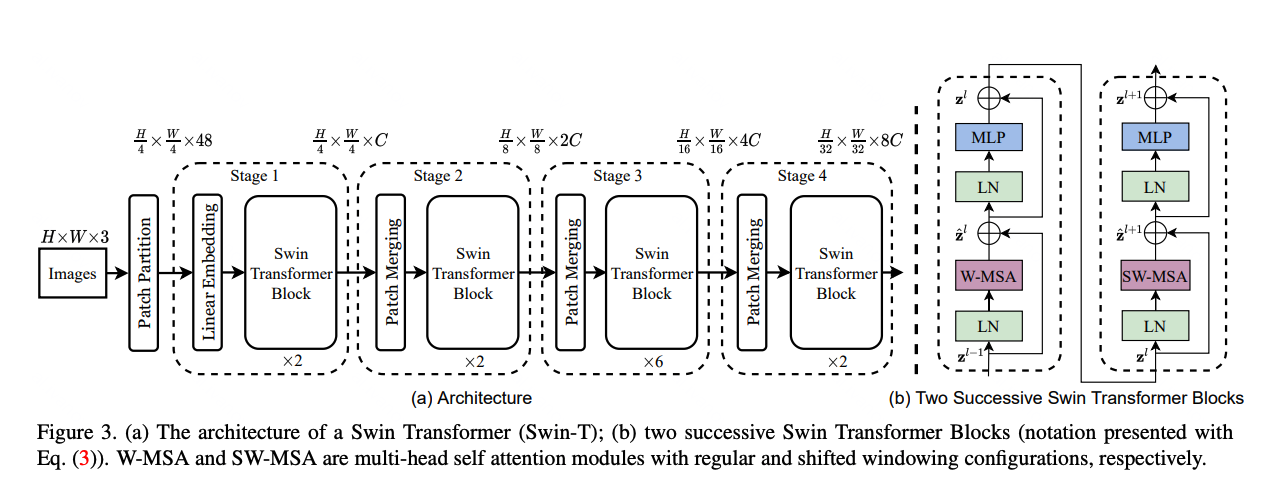

**Общая схема:**

1. **Patch Partition:** изображение разбивается на патчи $4 \times 4$
2. **Stage 1:** применяется Swin Transformer Block, разрешение остается
3. **Patch Merging:** объединение $2 \times 2$ соседних патчей → уменьшение разрешения в 2 раза
4. **Stage 2:** Swin Transformer Blocks на уменьшенном разрешении
5. **Повторение** для Stage 3 и Stage 4

**Иерархия разрешений:**

| Stage | Resolution | Channels | Описание |
|-------|-----------|----------|----------|
| Patch Partition | $\frac{H}{4} \times \frac{W}{4}$ | $C = 96$ | Начальная нарезка |
| Stage 1 | $\frac{H}{4} \times \frac{W}{4}$ | $C$ | Swin blocks |
| Patch Merging + Stage 2 | $\frac{H}{8} \times \frac{W}{8}$ | $2C$ | ×2 downsampling |
| Patch Merging + Stage 3 | $\frac{H}{16} \times \frac{W}{16}$ | $4C$ | ×2 downsampling |
| Patch Merging + Stage 4 | $\frac{H}{32} \times \frac{W}{32}$ | $8C$ | ×2 downsampling |

Это похоже на ResNet (stride 32), но с Transformer блоками!

#### Window-based Self-Attention

**Стандартный self-attention** (ViT):

Каждый патч смотрит на **все** остальные патчи.

Сложность: $\mathcal{O}(N^2 \cdot d)$, где $N = H/4 \times W/4$.

**Window-based self-attention** (Swin):

Изображение разбивается на **неперекрывающиеся окна** размера $M \times M$.

Внутри каждого окна применяется self-attention **локально**.

**Сложность:**

- Количество окон: $\frac{N}{M^2}$
- Attention внутри окна: $\mathcal{O}((M^2)^2 \cdot d) = \mathcal{O}(M^4 \cdot d)$
- Всего: $\mathcal{O}\left(\frac{N}{M^2} \cdot M^4 \cdot d\right) = \mathcal{O}(N \cdot M^2 \cdot d)$

**Для $M = 7$ (типичное значение):**

$$\text{Standard}: \mathcal{O}(N^2 \cdot d), \quad \text{Swin}: \mathcal{O}(49N \cdot d)$$

Ускорение пропорционально $\frac{N}{49}$ — огромное при больших $N$!

**Проблема:** Отсутствие связи между окнами → ограниченный receptive field.

#### Shifted Windows: ключевая идея

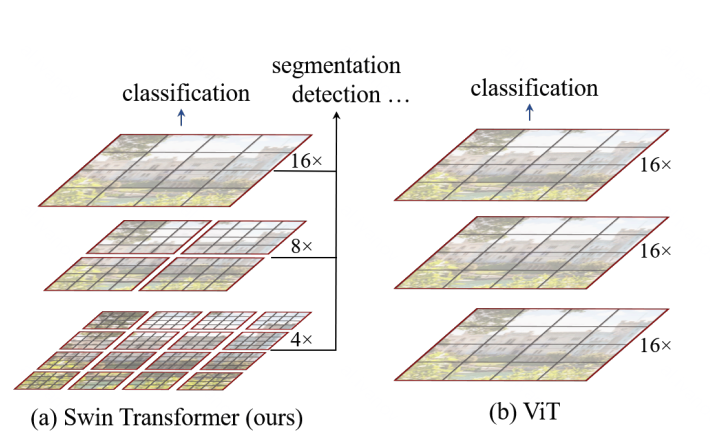

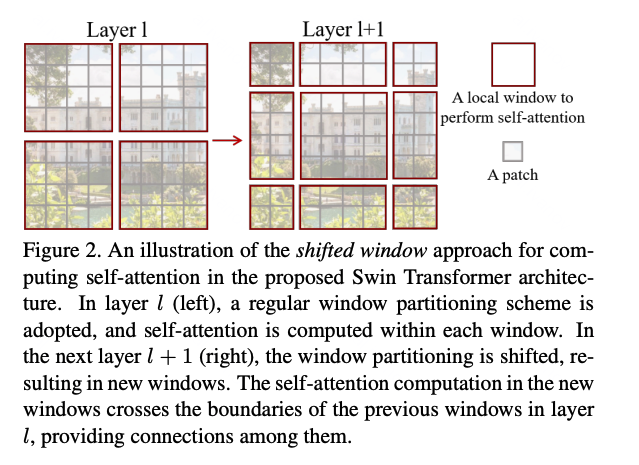

**Чередование двух типов разбиения:**

**Слой $\ell$ (четный):** Regular window partition

Окна выровнены по сетке с шагом $M$.

**Слой $\ell+1$ (нечетный):** Shifted window partition

Окна сдвинуты на $\left(\lfloor \frac{M}{2} \rfloor, \lfloor \frac{M}{2} \rfloor\right)$ пикселей.

**Эффект:** Окна в слое $\ell+1$ **перекрывают границы** окон из слоя $\ell$.

Это создает связи между разными окнами, позволяя информации распространяться по всему изображению.

**Пример:**

Пусть $M = 4$ (для простоты), изображение $8 \times 8$ патчей.

**Regular partition (слой $\ell$):**

```
+----+----+
| W1 | W2 |
+----+----+
| W3 | W4 |
+----+----+
```

4 окна $4 \times 4$.

**Shifted partition (слой $\ell+1$):**

Сдвиг на $(2, 2)$:

```
+--+------+--+
|  | W1'  |  |
+--+------+--+
| W3'  W2' |
+--+------+--+
|  | W4'  |  |
+--+------+--+
```

Окна пересекают границы предыдущих окон!

**Проблема со сдвигом:** Количество окон увеличивается (появляются маленькие окна на границах).

**Решение:** Cyclic shift — "заворачиваем" изображение, объединяя маленькие окна с противоположных сторон.

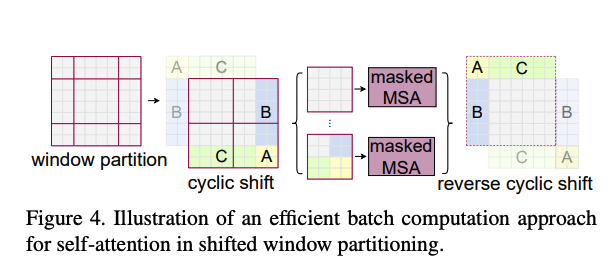

#### Relative Position Bias

В отличие от ViT (абсолютные позиционные эмбеддинги), Swin использует **relative position bias**.

В attention добавляется bias, зависящий от **относительной** позиции между патчами:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d}} + B\right)V$$

где $B \in \mathbb{R}^{M^2 \times M^2}$ — relative position bias matrix.

Для окна $M \times M$, относительные позиции лежат в диапазоне $[-(M-1), M-1]$ по каждой оси.

Всего различных относительных позиций: $(2M-1) \times (2M-1)$.

Создается learnable bias table $\hat{B} \in \mathbb{R}^{(2M-1) \times (2M-1)}$, из которой извлекаются значения для $B$.

**Преимущество:** Обобщается на разные размеры окон (можно интерполировать).

#### Swin Transformer Block

```
Input: [B, H, W, C]
    ↓
W-MSA (Window Multi-head Self-Attention)
    ↓
Add & Norm
    ↓
MLP
    ↓
Add & Norm
    ↓
SW-MSA (Shifted Window Multi-head Self-Attention)
    ↓
Add & Norm
    ↓
MLP
    ↓
Add & Norm
    ↓
Output: [B, H, W, C]
```

Два последовательных блока: один с regular windows, другой с shifted windows.



In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

def window_partition(x, window_size):
    """
    Разбиение тензора на неперекрывающиеся окна
    
    Args:
        x: (B, H, W, C)
        window_size: размер окна M
    Returns:
        windows: (B * num_windows, M, M, C)
    """
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows


def window_reverse(windows, window_size, H, W):
    """
    Обратное преобразование: из окон в исходную форму
    
    Args:
        windows: (B * num_windows, M, M, C)
        window_size: M
        H, W: высота и ширина изображения
    Returns:
        x: (B, H, W, C)
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x


class WindowAttention(nn.Module):
    """
    Window-based multi-head self-attention с relative position bias
    """
    def __init__(self, dim, window_size, num_heads):
        super().__init__()
        self.dim = dim
        self.window_size = window_size  # (M, M)
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        
        # Relative position bias table
        # Размер: (2*M-1, 2*M-1, num_heads)
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size[0] - 1) * (2 * window_size[1] - 1), num_heads)
        )
        
        # Индексы для относительных позиций
        coords_h = torch.arange(self.window_size[0])
        coords_w = torch.arange(self.window_size[1])
        coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing='ij'))  # 2, M, M
        coords_flatten = torch.flatten(coords, 1)  # 2, M*M
        
        # Вычисляем относительные координаты
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]  # 2, M*M, M*M
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()  # M*M, M*M, 2
        
        # Сдвигаем в положительный диапазон [0, 2*M-1]
        relative_coords[:, :, 0] += self.window_size[0] - 1
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        
        relative_position_index = relative_coords.sum(-1)  # M*M, M*M
        self.register_buffer("relative_position_index", relative_position_index)
        
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        
        nn.init.trunc_normal_(self.relative_position_bias_table, std=0.02)
    
    def forward(self, x, mask=None):
        """
        Args:
            x: (B*num_windows, M*M, C)
            mask: (num_windows, M*M, M*M) или None
        """
        B_, N, C = x.shape
        
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        q = q * self.scale
        attn = q @ k.transpose(-2, -1)
        
        # Добавляем relative position bias
        relative_position_bias = self.relative_position_bias_table[
            self.relative_position_index.view(-1)
        ].view(
            self.window_size[0] * self.window_size[1],
            self.window_size[0] * self.window_size[1],
            -1
        )
        relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous()
        attn = attn + relative_position_bias.unsqueeze(0)
        
        # Применяем маску для shifted windows
        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)
        
        attn = F.softmax(attn, dim=-1)
        
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        
        return x


class SwinTransformerBlock(nn.Module):
    """
    Swin Transformer Block
    """
    def __init__(self, dim, num_heads, window_size=7, shift_size=0, mlp_ratio=4.0):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size
        self.mlp_ratio = mlp_ratio
        
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(
            dim, window_size=(window_size, window_size), num_heads=num_heads
        )
        
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Linear(mlp_hidden_dim, dim)
        )
    
    def forward(self, x, mask_matrix):
        """
        Args:
            x: (B, H, W, C)
            mask_matrix: attention mask для shifted windows
        """
        B, H, W, C = x.shape
        
        shortcut = x
        x = self.norm1(x)
        
        # Cyclic shift
        if self.shift_size > 0:
            shifted_x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))
            attn_mask = mask_matrix
        else:
            shifted_x = x
            attn_mask = None
        
        # Partition windows
        x_windows = window_partition(shifted_x, self.window_size)  # (B*nW, M, M, C)
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)
        
        # Window attention
        attn_windows = self.attn(x_windows, mask=attn_mask)
        
        # Merge windows
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        shifted_x = window_reverse(attn_windows, self.window_size, H, W)
        
        # Reverse cyclic shift
        if self.shift_size > 0:
            x = torch.roll(shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))
        else:
            x = shifted_x
        
        # FFN
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        
        return x


# Пример использования
dim = 96
num_heads = 3
window_size = 7
H, W = 56, 56  # Должно делиться на window_size

# Два последовательных блока: regular + shifted
block1 = SwinTransformerBlock(dim, num_heads, window_size, shift_size=0)
block2 = SwinTransformerBlock(dim, num_heads, window_size, shift_size=window_size//2)

x = torch.randn(2, H, W, dim)

# Создание attention mask для shifted windows
# (в реальной реализации это делается один раз и кешируется)
mask_matrix = None  # Упрощенно

x = block1(x, mask_matrix)
x = block2(x, mask_matrix)

print(f"Output shape: {x.shape}")  # [2, 56, 56, 96]


Output shape: torch.Size([2, 56, 56, 96])



#### Преимущества и недостатки Swin

**Преимущества:**

1. **Линейная сложность:** $\mathcal{O}(N)$ вместо $\mathcal{O}(N^2)$
2. **Иерархическая структура:** multi-scale features, полезно для detection/segmentation
3. **SOTA результаты** на ImageNet, COCO, ADE20K

**Недостатки:**

1. **Сложная реализация:** cyclic shift, маски для shifted windows
2. **Сильно менее эффективна на GPU** по сравнению с ViT (из-за более сложного паттерна доступа к памяти)
3. **Ограниченная применимость** для задач с изначально последовательной структурой

**Где используется:**

- **Object Detection:** Swin используется как backbone в детекторах (Mask R-CNN, Cascade R-CNN)
- **Semantic Segmentation:** UperNet с Swin backbone — SOTA на ADE20K
- **Video Understanding:** Video Swin Transformer

---

### 4.2 CLIP: Contrastive Language-Image Pre-training

#### Архитектура CLIP

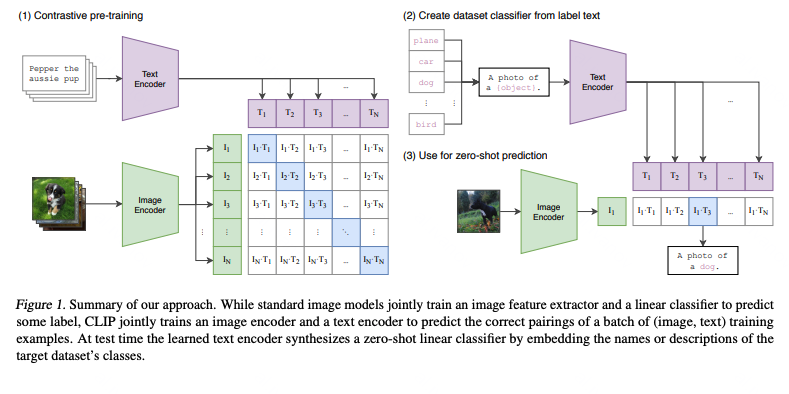

**CLIP состоит из двух encoder'ов:**

1. **Image Encoder:** $f_I: \mathcal{I} \to \mathbb{R}^d$
   - ResNet-50, ResNet-101, или ViT
   - Выход: image embedding $\mathbf{i} \in \mathbb{R}^d$

2. **Text Encoder:** $f_T: \mathcal{T} \to \mathbb{R}^d$
   - Transformer encoder (похож на BERT)
   - Использует [EOS] токен для агрегации
   - Выход: text embedding $\mathbf{t} \in \mathbb{R}^d$

**Оба encoder'а проецируют в общее пространство размерности $d$ (обычно 512).**

#### Contrastive Pre-training в CLIP

**Данные:** $N$ пар (image, caption) в батче.

**Процесс:**

1. Получаем эмбеддинги:
   - Images: $\mathbf{I} = [f_I(img_1), \ldots, f_I(img_N)]^T \in \mathbb{R}^{N \times d}$
   - Texts: $\mathbf{T} = [f_T(text_1), \ldots, f_T(text_N)]^T \in \mathbb{R}^{N \times d}$

2. Нормализуем (L2 norm):
   $$\mathbf{I} \leftarrow \frac{\mathbf{I}}{\|\mathbf{I}\|_2}, \quad \mathbf{T} \leftarrow \frac{\mathbf{T}}{\|\mathbf{T}\|_2}$$

3. Вычисляем матрицу схожести:
   $$\mathbf{S} = \mathbf{I} \mathbf{T}^T \in \mathbb{R}^{N \times N}$$
   
   $S_{ij} = \text{cosine\_sim}(f_I(img_i), f_T(text_j))$

4. Масштабируем температурой:
   $$\mathbf{S} \leftarrow \frac{\mathbf{S}}{\tau}$$
   
   где $\tau$ — learnable параметр (инициализируется как $\exp(-\tau_0)$, $\tau_0 \approx 2.6$).

5. **Symmetric cross-entropy loss:**

Для каждой пары $(img_i, text_i)$:

- **Image-to-text:** предсказываем правильный текст для изображения
  $$\mathcal{L}_{I \to T}^{(i)} = -\log \frac{\exp(S_{ii})}{\sum_{j=1}^{N} \exp(S_{ij})}$$

- **Text-to-image:** предсказываем правильное изображение для текста
  $$\mathcal{L}_{T \to I}^{(i)} = -\log \frac{\exp(S_{ii})}{\sum_{j=1}^{N} \exp(S_{ji})}$$

**Итоговая функция потерь:**

$$\mathcal{L}_{\text{CLIP}} = \frac{1}{2N} \sum_{i=1}^{N} \left( \mathcal{L}_{I \to T}^{(i)} + \mathcal{L}_{T \to I}^{(i)} \right)$$

Это эквивалентно:

$$\mathcal{L}_{\text{CLIP}} = \frac{1}{2} \left( \mathcal{H}(\mathbf{y}, \text{softmax}(\mathbf{S})) + \mathcal{H}(\mathbf{y}, \text{softmax}(\mathbf{S}^T)) \right)$$

где $\mathbf{y}$ — one-hot identity matrix (диагональ), $\mathcal{H}$ — cross-entropy.

**Интуиция:**

- Diagonal элементы $S_{ii}$ (правильные пары) должны быть **большими**
- Off-diagonal элементы $S_{ij}, i \neq j$ (неправильные пары) должны быть **маленькими**

```python
def clip_loss(logits_per_image, logits_per_text):
    """
    Symmetric cross-entropy loss
    """
    batch_size = logits_per_image.shape[0]
    labels = torch.arange(batch_size, device=logits_per_image.device)
    
    loss_i = F.cross_entropy(logits_per_image, labels)
    loss_t = F.cross_entropy(logits_per_text, labels)
    
    loss = (loss_i + loss_t) / 2
    return loss
```

#### Обучение CLIP: данные и архитектуры

**Данные:**

- **WIT (WebImageText):** 400 миллионов пар (image, text), собранных из интернета
- Разнообразные источники: соцсети, вики, новостные сайты, etc.
- Тексты: от коротких alt-text до длинных описаний
- Языки: в основном английский, но есть и другие

**Image Encoder варианты:**

1. **ResNet:** ResNet-50, ResNet-101
   - Modified: используется attention pooling вместо global average pooling

2. **Vision Transformer:** ViT-B/32, ViT-B/16, ViT-L/14
   - Лучшие результаты по сравнению с ResNet

**Text Encoder:**

- Transformer encoder (63M параметров)
- 12 слоев, 512 размерность, 8 голов
- Максимальная длина: 76 токенов
- BPE tokenization с vocab 49152

**Обучение:**

- Batch size: **32768** (огромный!)
- Mixed precision (FP16)
- Hardware: 592 V100 GPUs
- Время: ~2 недели
- Оптимизатор: Adam с linear learning rate decay

**Результаты:**

| Model | Zero-shot ImageNet Top-1 |
|-------|--------------------------|
| ResNet-50 (baseline) | 76.5% |
| CLIP ResNet-50 | **76.2%** |
| CLIP ResNet-101 | 77.3% |
| CLIP ViT-B/32 | 63.4% |
| CLIP ViT-B/16 | 68.3% |
| CLIP ViT-L/14 | **75.5%** |
| CLIP ViT-L/14@336px | **76.2%** |

**Удивительно:** Zero-shot CLIP на ViT-L достигает качества, близкого к ResNet-50, обученного на ImageNet!

#### Zero-shot классификация с CLIP на ImageNet

**Задача:** Классифицировать изображения на 1000 классов ImageNet без дообучения CLIP.

**Подход:**

1. Для каждого класса ImageNet создаем text prompt:
   ```
   "A photo of a {class_name}"
   ```
   
   Например: "A photo of a golden retriever", "A photo of a sports car"

2. Кодируем все 1000 промптов через text encoder:
   $$\mathbf{t}_k = f_T(\text{"A photo of a } c_k\text{"}), \quad k = 1, \ldots, 1000$$

3. Для изображения $img$, кодируем через image encoder:
   $$\mathbf{i} = f_I(img)$$

4. Вычисляем схожесть со всеми классами:
   $$\text{scores} = [\text{sim}(\mathbf{i}, \mathbf{t}_1), \ldots, \text{sim}(\mathbf{i}, \mathbf{t}_{1000})]$$

5. Предсказание:
   $$\hat{y} = \arg\max_k \text{scores}[k]$$

**Важно:** Можно улучшить качество, используя **ensemble промптов**:

```
"A photo of a {class}"
"A blurry photo of a {class}"
"A photo of a large {class}"
"A photo of a small {class}"
...
```

Усредняем эмбеддинги всех промптов для класса.



In [6]:
!pip install -U "huggingface_hub[cli]" transformers tokenizers mistral-common truststore

Looking in indexes: https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import truststore
truststore.inject_into_ssl()

In [4]:
from transformers import AutoProcessor, AutoModel, CLIPProcessor, CLIPModel
from PIL import Image
import torch
import requests
from io import BytesIO
import numpy as np

from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Computing text embeddings for all classes...
Text embeddings shape: torch.Size([14, 512])

Top-5 predictions:
1. oven: 0.3021
2. pizza in the oven: 0.3005
3. pizza: 0.2977
4. beach wagon: 0.1983
5. ostrich: 0.1975


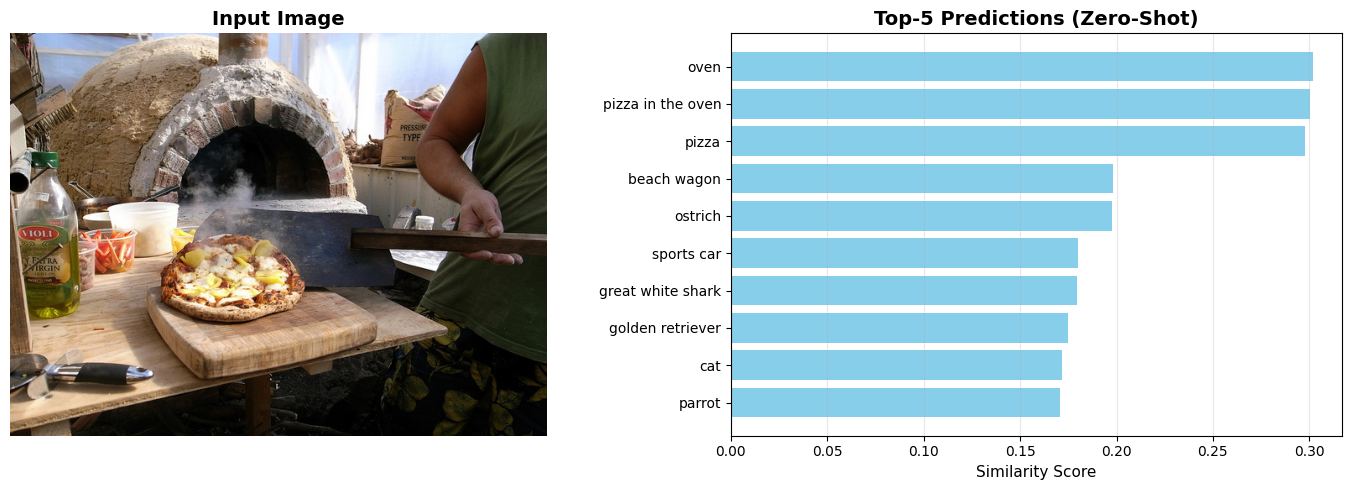

In [18]:

# ImageNet классы (пример - только несколько классов для демонстрации)
# В реальности нужно использовать все 1000 классов
imagenet_classes = [
    "tench", "goldfish", "great white shark", "tiger shark", "ostrich",
    "golden retriever", "Labrador retriever", "sports car","beach wagon", "pizza", "cat", "parrot", "oven", "pizza in the oven"
]

# Создаем текстовые промпты для zero-shot классификации
text_prompts = [f"a photo of a {cls}" for cls in imagenet_classes]

# Для улучшения качества - ensemble промптов (опционально)
template_prompts = [
    "a photo of a {}",
    "a blurry photo of a {}",
    "a photo of a large {}",
    "a photo of a small {}",
    "a photo of the {}",
]

def get_class_embeddings_ensemble(class_names, templates):
    """
    Вычисляет эмбеддинги классов с ensemble промптов
    """
    all_embeddings = []
    
    for cls in class_names:
        # Создаем все варианты промптов для класса
        prompts = [template.format(cls) for template in templates]
        
        # Получаем эмбеддинги
        inputs = processor(text=prompts, return_tensors="pt", padding=True)
        with torch.no_grad():
            text_features = model.get_text_features(**inputs).pooler_output
        
        # Усредняем
        cls_embedding = text_features.mean(dim=0)
        cls_embedding = cls_embedding / cls_embedding.norm()
        all_embeddings.append(cls_embedding)
    
    return torch.stack(all_embeddings)


# Получаем эмбеддинги всех классов
print("Computing text embeddings for all classes...")
text_embeddings = get_class_embeddings_ensemble(imagenet_classes, template_prompts)
print(f"Text embeddings shape: {text_embeddings.shape}")

# Загружаем тестовое изображение
url = "http://images.cocodataset.org/test-stuff2017/000000027107.jpg"
response = requests.get(url)
image = Image.open(BytesIO(response.content))

# Получаем эмбеддинг изображения
inputs = processor(images=image, return_tensors="pt")
with torch.no_grad():
    image_features = model.get_image_features(**inputs).pooler_output

# Нормализуем
image_features = image_features / image_features.norm(dim=-1, keepdim=True)

# Вычисляем схожесть со всеми классами
similarities = (image_features @ text_embeddings.T).squeeze(0)
similarities = similarities.cpu().numpy()

# Топ-5 предсказаний
top10_indices = np.argsort(similarities)[::-1][:10]
top10_classes = [imagenet_classes[i] for i in top10_indices]
top10_scores = [similarities[i] for i in top10_indices]

print("\nTop-5 predictions:")
for i, (cls, score) in enumerate(zip(top5_classes, top5_scores)):
    print(f"{i+1}. {cls}: {score:.4f}")

# Визуализация результатов
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Показываем изображение
axes[0].imshow(image)
axes[0].axis('off')
axes[0].set_title('Input Image', fontsize=14, fontweight='bold')

# Показываем топ-5 предсказаний
y_pos = np.arange(len(top10_classes))
axes[1].barh(y_pos, top10_scores, color='skyblue')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(top10_classes)
axes[1].invert_yaxis()
axes[1].set_xlabel('Similarity Score', fontsize=11)
axes[1].set_title('Top-5 Predictions (Zero-Shot)', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()




## Часть 4.3: CoCa - Contrastive Captioning

#### Мотивация: ограничения CLIP

**CLIP** отлично работает для:
- Zero-shot классификации
- Image-text retrieval
- Cross-modal alignment

**Но не может:**
- Генерировать описания изображений (image captioning)
- Отвечать на вопросы об изображении (VQA)
- Понимать детальные визуально-языковые связи

**Почему?** CLIP использует только **contrastive learning** — учится различать правильные и неправильные пары, но не генерировать текст.

**Решение CoCa:** объединить **contrastive** и **captioning** задачи в одной архитектуре!

#### Архитектура CoCa

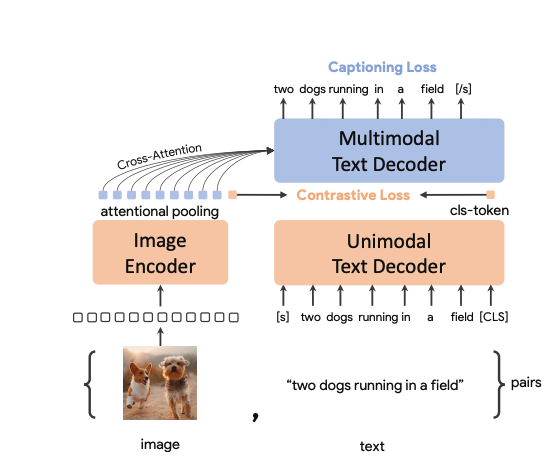

**CoCa (Contrastive Captioners)** состоит из трех компонентов:

1. **Image Encoder** (как в CLIP)
   - Vision Transformer или ConvNet
   - Выход: последовательность visual tokens $\mathbf{V} = [v_1, \ldots, v_M] \in \mathbb{R}^{M \times d}$

2. **Unimodal Text Decoder** (первая половина decoder слоев)
   - **Не смотрит на изображение** (нет cross-attention)
   - Обрабатывает только текст с causal masking
   - Используется для **contrastive loss**
   - Выход финального токена: text embedding для contrastive learning

3. **Multimodal Text Decoder** (вторая половина decoder слоев)
   - **С cross-attention к изображению**
   - Генерирует caption автрегрессивно
   - Используется для **captioning loss**

**Ключевая идея:** Декодер "расщепляется" на две части:

```
Text Input → Unimodal Decoder Layers (без cross-attn)
                    ↓
              [CLS] token → Contrastive Loss
                    ↓
          Multimodal Decoder Layers (с cross-attn к image)
                    ↓
             Generated Tokens → Captioning Loss
```

#### Математическая формализация

**1. Image Encoding:**

$$\mathbf{V} = \text{ImageEncoder}(\text{image})$$

Добавляем [CLS] токен для image embedding:

$$\mathbf{i} = \text{Pool}(\mathbf{V})$$

(обычно берется [CLS] токен или mean pooling)

**2. Unimodal Text Decoding:**

Входной текст: $[w_1, w_2, \ldots, w_n]$

Проходит через первые $L_{\text{uni}}$ слоев decoder **без cross-attention**:

$$\mathbf{H}^{\text{uni}} = \text{UnimodalDecoder}([w_1, \ldots, w_n])$$

Берем embedding финального [CLS] токена:

$$\mathbf{t} = \mathbf{H}^{\text{uni}}_{[\text{CLS}]}$$

**3. Multimodal Text Decoding:**

$\mathbf{H}^{\text{uni}}$ передается в следующие $L_{\text{multi}}$ слоев с **cross-attention к image**:

$$\mathbf{H}^{\text{multi}} = \text{MultimodalDecoder}(\mathbf{H}^{\text{uni}}, \mathbf{V})$$

Эти слои используют cross-attention:

$$\text{CrossAttention}(Q=\mathbf{H}^{\text{uni}}, K=\mathbf{V}, V=\mathbf{V})$$

#### Функции потерь

**1. Contrastive Loss** (как в CLIP):

Используем unimodal text embedding $\mathbf{t}$ и image embedding $\mathbf{i}$:

$$\mathcal{L}_{\text{con}} = \frac{1}{2N} \sum_{i=1}^{N} \left( -\log \frac{e^{\mathbf{i}_i \cdot \mathbf{t}_i / \tau}}{\sum_{j=1}^N e^{\mathbf{i}_i \cdot \mathbf{t}_j / \tau}} - \log \frac{e^{\mathbf{t}_i \cdot \mathbf{i}_i / \tau}}{\sum_{j=1}^N e^{\mathbf{t}_j \cdot \mathbf{i}_i / \tau}} \right)$$

**2. Captioning Loss** (cross-entropy):

Автрегрессивная генерация caption:

$$\mathcal{L}_{\text{cap}} = -\sum_{t=1}^{T} \log P(w_t | w_{<t}, \text{image})$$

где вероятность вычисляется из multimodal decoder:

$$P(w_t | w_{<t}, \text{image}) = \text{softmax}(\mathbf{W} \mathbf{H}^{\text{multi}}_t)$$

**Итоговая функция потерь:**

$$\mathcal{L} = \lambda_{\text{con}} \mathcal{L}_{\text{con}} + \lambda_{\text{cap}} \mathcal{L}_{\text{cap}}$$

В оригинальной статье: $\lambda_{\text{con}} = 1.0$, $\lambda_{\text{cap}} = 2.0$

#### Преимущества CoCa

1. **Единая архитектура** для contrastive и generative задач
2. **Эффективность:** один forward pass вычисляет оба loss
3. **Гибкость:** можно использовать только image encoder + unimodal decoder для CLIP-подобных задач
4. **SOTA результаты** на многих бенчмарках:
   - ImageNet zero-shot: 86.3%
   - COCO captioning: CIDEr 140+
   - VQA: 82.3%

#### Обучение CoCa

**Данные:**

- **Annotated images:** COCO, Conceptual Captions (высокое качество captions)
- **Noisy image-text pairs:** ALIGN dataset (1.8B пар из интернета)

**Трюк:** Рассматриваем ImageNet labels как текст!

Например, label "golden retriever" → caption "golden retriever"

Это позволяет использовать classification данные для обучения VLM.

**Архитектурные детали:**

- Image encoder: ViT-L (307M params)
- Total decoder layers: 12
  - Unimodal: первые 6 слоев
  - Multimodal: последние 6 слоев
- Embedding dimension: 768
- Batch size: 16384 (огромный для contrastive learning!)


### 4.4 SigLIP - Sigmoid Loss for Language-Image Pre-training

#### Проблема softmax в CLIP

**Напомним CLIP loss:**

Для батча размера $N$, матрица схожести $\mathbf{S} \in \mathbb{R}^{N \times N}$:

$$\mathcal{L}_{\text{CLIP}}^{(i)} = -\log \frac{e^{S_{ii}/\tau}}{\sum_{j=1}^N e^{S_{ij}/\tau}}$$

**Проблемы:**

1. **Global normalization:** Нужен доступ ко **всему батчу** для вычисления softmax
2. **Distributed training:** При распределении батча по GPU требуется синхронизация (all-gather операция)
3. **Memory overhead:** Матрица $N \times N$ при больших $N$ (32k+) занимает много памяти
4. **Small batch performance:** При маленьких батчах ($N < 1024$) качество падает

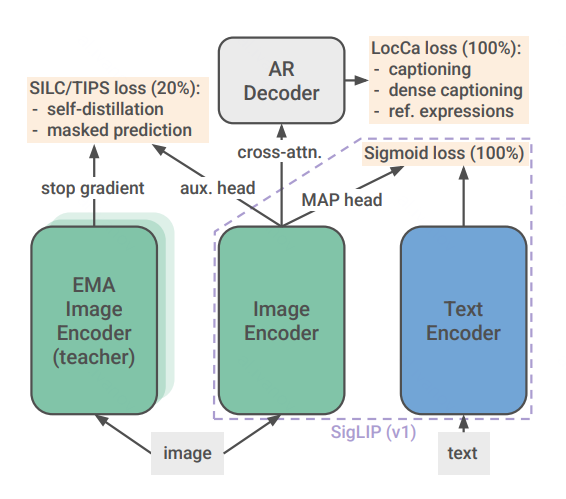

#### Идея SigLIP: pairwise sigmoid loss

**Ключевое наблюдение:** Softmax создает **зависимость** между всеми парами в батче.

**Альтернатива:** Рассматривать каждую пару **независимо** с sigmoid!

**Sigmoid loss для пары $(i, j)$:**

$$\mathcal{L}_{\text{sig}}^{(i,j)} = -\log \sigma(z_t \cdot S_{ij})$$

где:
- $S_{ij}$ — cosine similarity между image $i$ и text $j$
- $z_t \in \{-1, +1\}$ — метка: $+1$ если пара правильная (matching), $-1$ если неправильная
- $\sigma(x) = \frac{1}{1 + e^{-x}}$ — sigmoid функция

**Переписываем:**

$$\mathcal{L}_{\text{sig}}^{(i,j)} = \log(1 + e^{-z_t \cdot S_{ij}})$$

Это **binary cross-entropy loss** для каждой пары!

**Для батча из $N$ пар:**

- $N$ positive пар: $(i, i)$ с меткой $+1$
- $N^2 - N$ negative пар: $(i, j), i \neq j$ с меткой $-1$

$$\mathcal{L}_{\text{SigLIP}} = \frac{1}{N^2} \sum_{i=1}^N \sum_{j=1}^N \log(1 + e^{-z_{ij} \cdot S_{ij}})$$

где $z_{ij} = \begin{cases} +1 & \text{if } i = j \\ -1 & \text{otherwise} \end{cases}$

**Симметризация (как в CLIP):**

$$\mathcal{L}_{\text{SigLIP}} = \frac{1}{2} \left( \mathcal{L}_{\text{SigLIP}}^{\text{I→T}} + \mathcal{L}_{\text{SigLIP}}^{\text{T→I}} \right)$$

#### Зачем нужна sigmoid?

**Преимущества sigmoid loss:**

1. **No global normalization:** Каждая пара обрабатывается **независимо**
   - Не нужен all-gather для распределенного обучения
   - Можно вычислять loss по частям

2. **Better at small batch sizes:** Softmax требует много negatives, sigmoid работает и с малым батчем

3. **Simpler implementation:** Нет температурного параметра (заменен на bias)

4. **Scalability:** Можно увеличивать батч до 1M+ без проблем

**Добавление bias:**

В оригинальной SigLIP добавляется learnable **bias term** $b$:

$$\mathcal{L}_{\text{SigLIP}}^{(i,j)} = \log(1 + e^{-z_{ij} \cdot (S_{ij} + b)})$$

**Интуиция:** Bias сдвигает prior в сторону negatives, компенсируя imbalance (больше negative пар).

#### Сравнение CLIP vs SigLIP

| Аспект | CLIP (Softmax) | SigLIP (Sigmoid) |
|--------|---------------|-----------------|
| **Normalization** | Global (весь батч) | Pairwise (независимо) |
| **Batch size dependency** | Сильная (качество ↑ с ростом $N$) | Слабая |
| **Small batch ($N < 1k$)** | Хуже | **Лучше** |
| **Large batch ($N > 32k$)** | Хорошо | **Сравнимо/лучше** |
| **Distributed training** | Требует синхронизация | **Нет синхронизации** |
| **Parameters** | Temperature $\tau$ | Bias $b$ |

**Экспериментальные результаты (из статьи):**

| Batch Size | CLIP Accuracy | SigLIP Accuracy |
|------------|---------------|-----------------|
| 512 | 65.3% | **68.7%** |
| 4k | 70.2% | **71.3%** |
| 16k | 72.6% | **72.8%** |
| 32k | 73.1% | **73.4%** |

SigLIP лучше на малых батчах и сравним на больших!

#### Архитектуры в SigLIP

**Текстовый encoder:**

- Transformer с 12 слоями
- 512 размерность
- 8 attention heads
- Vocab size: 32k (SentencePiece)

**Image encoder:**

1. **ViT-B/16:** 86M params, patch size 16
2. **ViT-L/16:** 307M params
3. **ViT-SO400M/14:** огромная модель, обученная на внутренних данных Google

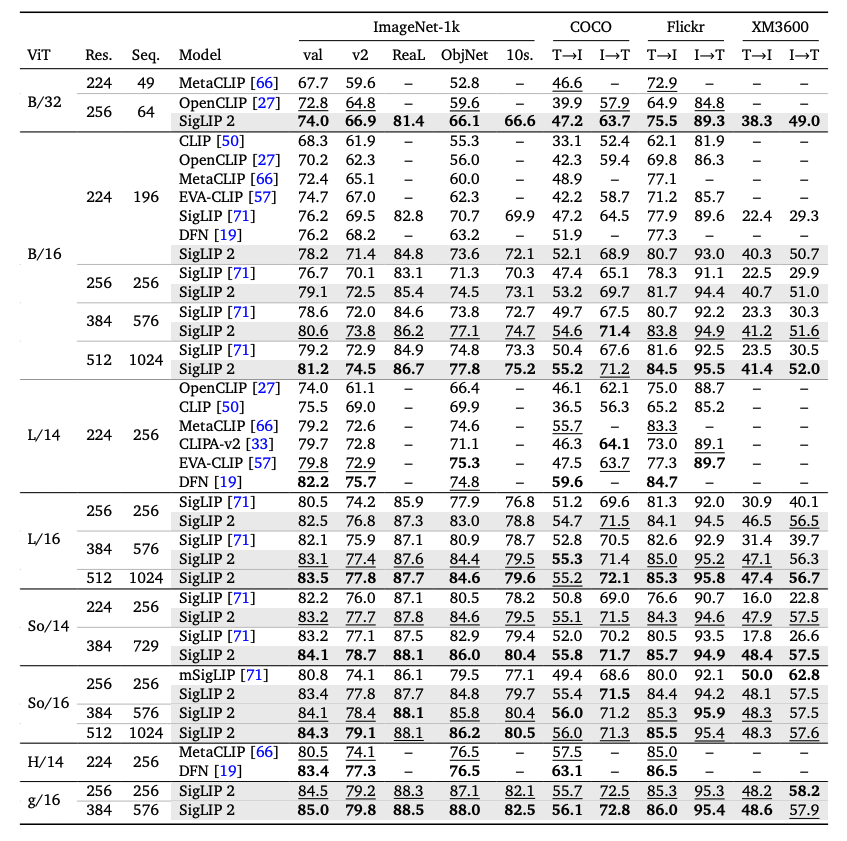

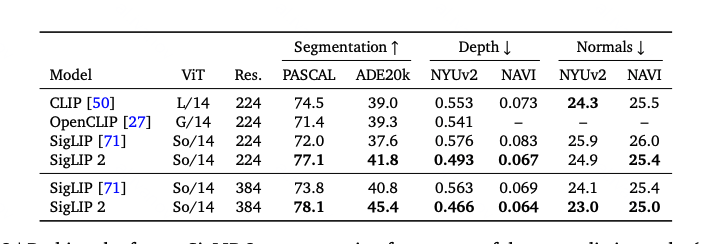



## Часть 5: NaViT, NaFlex и работа с произвольными разрешениями

### 5.1 Мотивация: проблема фиксированного разрешения

**Традиционный подход в ViT и SigLIP:**

Все изображения **ресайзятся** к фиксированному разрешению (например, 224×224):

```python
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])
```

**Проблемы этого подхода:**

1. **Искажение пропорций (aspect ratio distortion):**
   - Изображение 800×600 (4:3) → 224×224 (1:1)
   - Вертикальный объект становится "сплющенным"
   - Горизонтальный объект становится "растянутым"

2. **Потеря информации:**
   - При crop'е теряются части изображения
   - Важные объекты могут быть обрезаны

3. **Неэффективное использование вычислений:**
   - Маленькие изображения "раздуваются" до большого размера
   - Вычисляем attention для padding'а или артефактов ресайза

**Пример проблемы:**

```
Оригинал (1600×400, 4:1):
┌───────────────────────────────────────┐
│    [длинная панорама с объектами]     │
└───────────────────────────────────────┘

После Resize + CenterCrop (224×224):
┌──────┐
│ [??] │  ← потеряны 90% изображения!
└──────┘
```

**Что хотим:**

- Обрабатывать изображения **любого разрешения** и **любого aspect ratio**
- Сохранять **нативные пропорции**
- Эффективно использовать вычисления (маленькие изображения → меньше патчей)

---

### 5.2 NaViT: Native Resolution ViT

**СЮДА ВСТАВИТЬ СХЕМУ NAVIT ИЗ СТАТЬИ (Figure 1/2)**

**NaViT (Native Resolution ViT)** — расширение ViT для работы с **переменным числом патчей**.

#### Ключевая идея

**В стандартном ViT:**

- Фиксированное число патчей: $N = \frac{224^2}{16^2} = 196$
- Все изображения в батче имеют **одинаковую** длину последовательности

**В NaViT:**

- **Переменное** число патчей в зависимости от размера изображения
- Разные изображения в батче имеют **разное** число патчей

**Математически:**

Для изображения размера $H \times W$ и patch size $P$:

$$N = \frac{H}{P} \times \frac{W}{P}$$

**Примеры:**

| Изображение | Разрешение | Num Patches ($P=16$) |
|-------------|-----------|---------------------|
| Квадрат | 224×224 | 196 |
| Вертикальное | 224×448 | 392 |
| Горизонтальное | 448×224 | 392 |
| Панорама | 896×224 | 784 |
| Маленькое | 128×128 | 64 |

**Проблема:** Как батчить изображения с **разным числом патчей**?

#### Решение: Token Packing

**Идея:** "Упаковываем" несколько изображений в одну последовательность фиксированной длины.

**Алгоритм:**

1. Задаем максимальную длину последовательности $L_{\max}$ (например, 1024)
2. В каждый элемент батча "запихиваем" столько изображений, сколько влезет

**Пример:**

```
Batch element 1: [img1 (196 tokens) | img2 (196 tokens) | img3 (196 tokens) | img4 (196 tokens) | padding (40)]
Batch element 2: [img5 (392 tokens) | img6 (392 tokens) | padding (240)]
Batch element 3: [img7 (64 tokens) | img8 (64 tokens) | img9 (64 tokens) | ... | img20 (64 tokens)]
```

**Преимущества:**

- Эффективное использование вычислений (мало padding'а)
- Фиксированный batch size для hardware

**Проблема:** Нужен механизм, чтобы attention **не перемешивал** разные изображения!

#### Attention Masking для Token Packing

**Задача:** Патчи из image 1 не должны attend к патчам из image 2.

**Решение:** Используем **attention mask**:

$$\text{mask}[i, j] = \begin{cases} 
0 & \text{если патч } i \text{ и патч } j \text{ из одного изображения} \\
-\infty & \text{иначе}
\end{cases}$$

**Визуализация маски:**

```
Последовательность: [img1 (4 tokens) | img2 (3 tokens) | padding (1)]

Attention mask (8×8):
      0  1  2  3  4  5  6  7
   ┌─────────────────────────┐
 0 │ 0  0  0  0 -∞ -∞ -∞ -∞  │ img1
 1 │ 0  0  0  0 -∞ -∞ -∞ -∞  │ img1
 2 │ 0  0  0  0 -∞ -∞ -∞ -∞  │ img1
 3 │ 0  0  0  0 -∞ -∞ -∞ -∞  │ img1
 4 │-∞ -∞ -∞ -∞  0  0  0 -∞  │ img2
 5 │-∞ -∞ -∞ -∞  0  0  0 -∞  │ img2
 6 │-∞ -∞ -∞ -∞  0  0  0 -∞  │ img2
 7 │-∞ -∞ -∞ -∞ -∞ -∞ -∞  0  │ padding
   └─────────────────────────┘
```

#### Masked Position Embeddings

**Проблема:** В стандартном ViT position embeddings — это вектор размерности $(N+1) \times D$.

Для $N=196$ имеем 197 position embeddings (включая [CLS]).

**Что делать, если изображение имеет 392 патча?**

**Решение:** **Интерполяция** position embeddings.

**2D Position Embeddings:**

Представляем position embeddings как 2D grid:

$$\mathbf{E}_{\text{pos}} \in \mathbb{R}^{\sqrt{N} \times \sqrt{N} \times D}$$

Для $N=196$: $14 \times 14 \times D$.

**Для изображения $H \times W$:**

1. Вычисляем размер 2D grid патчей: $h = H/P, w = W/P$
2. Интерполируем position embeddings до размера $h \times w$:

$$\mathbf{E}_{\text{pos}}^{\text{interp}} = \text{Interpolate}(\mathbf{E}_{\text{pos}}, (h, w))$$

**Методы интерполяции:**

- **Bilinear interpolation** (используется в NaViT / Siglip2)

### 5.4 SigLIP2-SO400M-Patch16-NaFlex

#### Архитектура модели

**Полное название:** `google/siglip2-so400m-patch16-naflex`

**Компоненты:**

1. **Vision Encoder:**
   - Vision Transformer (ViT)
   - Patch size: 16×16
   - Model size: SO400M (So - shape optimized - ~400M параметров)
   - Поддержка переменного числа патчей (NaFlex)

2. **Text Encoder:**
   - Transformer encoder (как в BERT)
   - Vocab size: 32k
   - Max sequence length: 64

3. **Projection heads:**
   - Vision projection: $D_{\text{vision}} \to D_{\text{embed}}$
   - Text projection: $D_{\text{text}} \to D_{\text{embed}}$
   - $D_{\text{embed}} = 1152$ (embedding dimension)

#### Препроцессор с бинарным поиском

**Задача:** Найти максимальное разрешение $(H, W)$, которое:

1. Сохраняет aspect ratio оригинального изображения
2. Число патчей $\leq$ `max_tokens` (4096)
3. $H$ и $W$ кратны `patch_size` (16)

**Математическая формулировка:**

$$\max_{H, W} H \times W$$

$$\text{subject to: } \frac{H}{16} \times \frac{W}{16} \leq 4096$$

$$\frac{W}{H} = \frac{W_{\text{orig}}}{H_{\text{orig}}}$$

$$H \equiv 0 \pmod{16}, \quad W \equiv 0 \pmod{16}$$

**Алгоритм бинарного поиска:**


In [26]:
from transformers.models.siglip2.image_processing_siglip2_fast import Siglip2ImageProcessorFast
from transformers.models.siglip2.image_processing_siglip2 import get_image_size_for_max_num_patches

?? get_image_size_for_max_num_patches

Signature:      
 get_image_size_for_max_num_patches(
    image_height: int,
    image_width: int,
    patch_size: int,
    max_num_patches: int,
    eps: float = 1e-05,
) -> tuple[int, int]
Call signature:   get_image_size_for_max_num_patches(*args, **kwargs)
Type:            _lru_cache_wrapper
String form:     <functools._lru_cache_wrapper object at 0x317b5d850>
File:            ~/venv/lib/python3.12/site-packages/transformers/models/siglip2/image_processing_siglip2.py
Source:         
@lru_cache(maxsize=256)
def get_image_size_for_max_num_patches(
    image_height: int, image_width: int, patch_size: int, max_num_patches: int, eps: float = 1e-5
) -> tuple[int, int]:
    """
    Determine image size based on max number of patches, ensure dimensions are divisible by patch size and image is at least 1 patch.

    Args:
        image_height (`int`):
            Original image height.
        image_width (`int`):
            Original image width.
        patch_size (`int`):
            Pa